
Continuous columns to scale: ['hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos', 'temp', 'atemp', 'hum', 'windspeed']
All columns: ['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'weathersit_4']

Column order: ['hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos', 'temp', 'atemp', 'hum', 'windspeed', 'yr', 'holiday', 'workingday', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'weathersit_4']

Scaled columns 1 to 10 (continuous features)
Unscaled columns 11 to 19 (categorical/binary features)

Using random_state = 1763439765
Train samples: 13903
Test samples: 3476
Feature matrix shape: (13903, 20)
Bootstrap 1 shape: X=(13903, 20), y=(13903,)
Bootstrap 2 shape: X=(13903, 20), y=(13903,)
Bootstrap 3 shape: X=(13903, 20), y=(13903,)


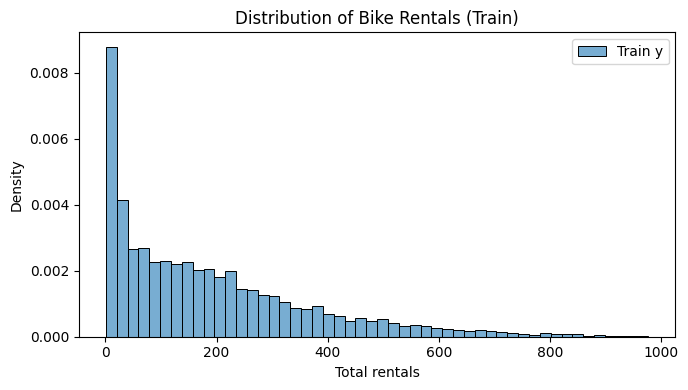


✓ Preprocessing complete! Data ready for modeling.
y min: 1
y max: 977
y range: (np.int64(1), np.int64(977))


In [640]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo
import time

def preprocess_bikesharing(df, target_col='cnt'):
    """
    Preprocess bike sharing data with explicit tracking of continuous vs categorical features.
    Returns: processed df, target y, and list of continuous column names
    """
    df = df.copy()
    df.drop(columns=['dteday', 'instant'], inplace=True, errors='ignore')
    
    # Track continuous columns (will need scaling)
    continuous_cols = []
    
    # Add cyclic features for temporal variables
    def add_cyclic(df, col, period):
        if col in df.columns:
            sin_col = f'{col}_sin'
            cos_col = f'{col}_cos'
            df[sin_col] = np.sin(2 * np.pi * df[col] / period)
            df[cos_col] = np.cos(2 * np.pi * df[col] / period)
            continuous_cols.extend([sin_col, cos_col])  # Cyclic features are continuous
            df.drop(columns=[col], inplace=True)
        return df
    
    for col, period in [('hr', 24), ('mnth', 12), ('weekday', 7)]:
        df = add_cyclic(df, col, period)
    
    # Original continuous features (temp, atemp, hum, windspeed)
    original_continuous = ['temp', 'atemp', 'hum', 'windspeed']
    continuous_cols.extend([c for c in original_continuous if c in df.columns])
    
    # Binary columns stay as-is (0/1, no scaling needed)
    binary_cols = ['yr', 'holiday', 'workingday']
    
    # One-hot encode categorical variables
    categorical_cols = ['season', 'weathersit']
    existing_cats = [c for c in categorical_cols if c in df.columns]
    df = pd.get_dummies(df, columns=existing_cats, drop_first=True)
    
    # Remove registered and casual (they sum to target)
    df.drop(columns=['registered', 'casual'], inplace=True, errors='ignore')
    
    # Extract target
    y = df[target_col] if target_col in df.columns else None
    df.drop(columns=[target_col], inplace=True, errors='ignore')
    
    # Ensure all columns are numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df, y, continuous_cols


# --------------------------------------------------------------------
# Load and preprocess dataset
# --------------------------------------------------------------------
bike_sharing = fetch_ucirepo(id=275)
df = bike_sharing.data.original

df_processed, y, continuous_cols = preprocess_bikesharing(df, target_col='cnt')

print(f"\nContinuous columns to scale: {continuous_cols}")
print(f"All columns: {df_processed.columns.tolist()}")

# --------------------------------------------------------------------
# Organize columns: continuous first, then categorical/binary
# --------------------------------------------------------------------
categorical_binary_cols = [c for c in df_processed.columns if c not in continuous_cols]
df_ordered = df_processed[continuous_cols + categorical_binary_cols]

print(f"\nColumn order: {df_ordered.columns.tolist()}")

# Convert to numpy
X_raw = df_ordered.to_numpy().astype(float)

# --------------------------------------------------------------------
# Add intercept column
# --------------------------------------------------------------------
X = np.hstack([np.ones((X_raw.shape[0], 1)), X_raw])

# --------------------------------------------------------------------
# Scale ONLY continuous columns
# Intercept = column 0
# Continuous = columns 1 to 1+len(continuous_cols)
# Categorical/Binary = remaining columns (unscaled)
# --------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = X.copy()

# Scale only continuous features
cont_start = 1
cont_end = 1 + len(continuous_cols)
X_scaled[:, cont_start:cont_end] = scaler.fit_transform(X[:, cont_start:cont_end])

print(f"\nScaled columns {cont_start} to {cont_end-1} (continuous features)")
print(f"Unscaled columns {cont_end} to {X.shape[1]-1} (categorical/binary features)")

X = X_scaled

# --------------------------------------------------------------------
# Train/test split
# --------------------------------------------------------------------
seed = int(time.time())
print(f"\nUsing random_state = {seed}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=seed
)

y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

print(f"Train samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")
print(f"Feature matrix shape: {X_train.shape}")

# --------------------------------------------------------------------
# Create bootstraps
# --------------------------------------------------------------------
n_bootstraps = 3
n_train = len(y_train)
base_ss = np.random.SeedSequence(123)
child_ss = base_ss.spawn(n_bootstraps)

bootstraps = []
for b, ss in enumerate(child_ss, start=1):
    rng = np.random.default_rng(ss)
    idx = rng.integers(0, n_train, size=n_train, endpoint=False)
    X_bs = X_train[idx]
    y_bs = y_train[idx]
    bootstraps.append((X_bs, y_bs))
    print(f"Bootstrap {b} shape: X={X_bs.shape}, y={y_bs.shape}")

# --------------------------------------------------------------------
# Plot target distribution
# --------------------------------------------------------------------
plt.figure(figsize=(7, 4))
sns.histplot(y_train, bins=50, stat="density", alpha=0.6, label="Train y")
plt.title("Distribution of Bike Rentals (Train)")
plt.xlabel("Total rentals")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------
# Save for downstream use
# --------------------------------------------------------------------
X_train_np = X_train
X_test_np = X_test
y_train_np = y_train
y_test_np = y_test

print("\n✓ Preprocessing complete! Data ready for modeling.")
print("y min:", y.min())
print("y max:", y.max())
print("y range:", (y.min(), y.max()))

In [641]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from ucimlrepo import fetch_ucirepo
# import time

# # Load dataset
# bike_sharing = fetch_ucirepo(id=275)
# df = bike_sharing.data.original

# # Preprocess with your function
# df_processed, y = preprocess_bikesharing(df, target_col='cnt')

# # --------------------------------------------------------------------
# # FIX 1 — Split continuous vs boolean columns
# # --------------------------------------------------------------------
# # Ensure booleans become numerical (0/1) but UNSCALED
# print(df_processed.dtypes)
# one_hot = df_processed.select_dtypes(include=['bool']).columns.tolist()
# binary = df_processed.select_dtypes(include=['int64']).columns.tolist()
# cont_cols = df_processed.select_dtypes(include=['float64']).columns.tolist()


# # Keep ordering: continuous first, then booleans
# df_final = df_processed[cont_cols + one_hot + binary]

# # Convert to numpy
# X_raw = df_final.to_numpy().astype(float)

# # --------------------------------------------------------------------
# # FIX 2 — Add intercept column ONCE
# # --------------------------------------------------------------------
# X = np.hstack([np.ones((X_raw.shape[0], 1)), X_raw])

# # --------------------------------------------------------------------
# # FIX 3 — Standardize ONLY continuous columns
# # Intercept = col 0
# # Cont columns = next len(cont_cols) columns
# # Bool columns = remain unscaled
# # --------------------------------------------------------------------
# scaler = StandardScaler()

# X_scaled = X.copy()
# # scale only the continuous part
# X_scaled[:, 1:1+len(cont_cols)] = scaler.fit_transform(X[:, 1:1+len(cont_cols)])

# # X_scaled is the final design matrix
# X = X_scaled

# # --------------------------------------------------------------------
# # Train/test split
# # --------------------------------------------------------------------
# seed = int(time.time())
# print("Using random_state =", seed)

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, shuffle=True, random_state=seed
# )

# y_train = np.asarray(y_train)
# y_test  = np.asarray(y_test)

# print("Train samples:", len(y_train))
# print("Test samples:", len(y_test))

# # --------------------------------------------------------------------
# # Bootstraps
# # --------------------------------------------------------------------
# n_bootstraps = 3
# n_train = len(y_train)

# base_ss = np.random.SeedSequence(123)
# child_ss = base_ss.spawn(n_bootstraps)

# bootstraps = []
# for b, ss in enumerate(child_ss, start=1):
#     rng = np.random.default_rng(ss)
#     idx = rng.integers(0, n_train, size=n_train, endpoint=False)
#     X_bs = X_train[idx]
#     y_bs = y_train[idx]
#     bootstraps.append((X_bs, y_bs))
#     print(f"Bootstrap {b} shape: X={X_bs.shape}, y={y_bs.shape}")

# # --------------------------------------------------------------------
# # Plot target distribution
# # --------------------------------------------------------------------
# plt.figure(figsize=(7, 4))
# sns.histplot(y_train, bins=50, stat="density", alpha=0.6, label="Train y")
# plt.title("Distribution of Bike Rentals (Train)")
# plt.xlabel("Total rentals")
# plt.ylabel("Density")
# plt.legend()
# plt.show()

# # Save for downstream (VI models)
# X_train_np = X_train
# X_test_np  = X_test
# y_train_np = y_train
# y_test_np  = y_test






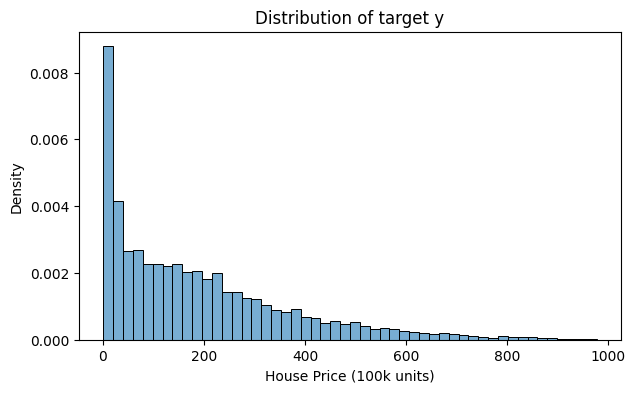

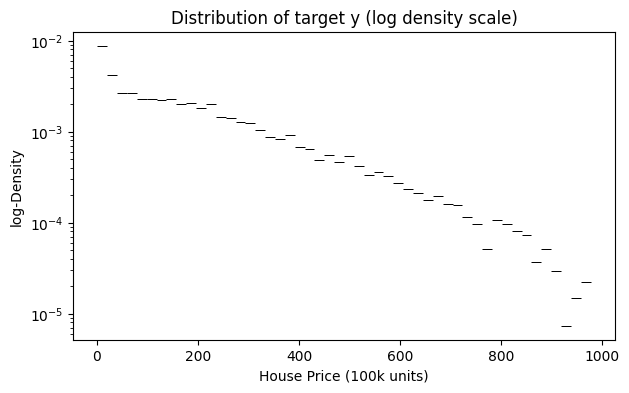

Skewness: 1.2782900087941667
Kurtosis: 1.4210558020051431


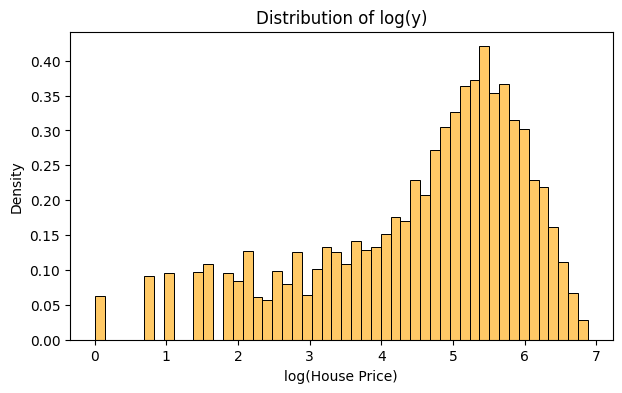

In [642]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
plt.figure(figsize=(7,4))
sns.histplot(y_train, bins=50, stat="density", alpha=0.6)
plt.title("Distribution of target y")
plt.xlabel("House Price (100k units)")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(y_train, bins=50, stat="density", alpha=0.6, log_scale=(False, True))
plt.title("Distribution of target y (log density scale)")
plt.xlabel("House Price (100k units)")
plt.ylabel("log-Density")
plt.show()

print("Skewness:", skew(y_train))
print("Kurtosis:", kurtosis(y_train))
plt.figure(figsize=(7,4))
sns.histplot(np.log(y_train), bins=50, stat="density", alpha=0.6, color="orange")
plt.title("Distribution of log(y)")
plt.xlabel("log(House Price)")
plt.ylabel("Density")
plt.show()


In [643]:
import numpy as np
from sklearn.metrics import pairwise_distances

dists = pairwise_distances(y_train.reshape(-1,1))
sigma_mmd = np.median(dists)
print(sigma_mmd)

148.0


In [644]:
import torch
import numpy as np


n_features = X_train_np.shape[1]   
mean_y = float(y_train_np.mean())             
log_mean_y = np.log(mean_y)                    
prior_mean_beta = torch.zeros(n_features, dtype=torch.float32)
prior_mean_beta[0] = log_mean_y                
prior_sd_intercept = 0.1
prior_sd_coeffs    = 1.0       

prior_sd = torch.tensor(
    [prior_sd_intercept] + [prior_sd_coeffs] * (n_features - 1),
    dtype=torch.float32,
)

prior_var = prior_sd ** 2
prior_cov_inv = torch.diag(1.0 / prior_var)
logdet_prior_cov = torch.log(prior_var).sum()
prior_lambda_alpha = torch.tensor(1.0, dtype=torch.float32)
prior_mean_alpha   = 1.0 / prior_lambda_alpha                
prior_var_alpha    = 1.0 / (prior_lambda_alpha ** 2)          
prior_median_alpha = torch.log(torch.tensor(2.0)) / prior_lambda_alpha  



In [645]:
import torch
import torch.nn as nn
import numpy as np


class VariationalNBRegression(nn.Module):
    """
    Mean-field variational family for NB regression using α (dispersion):

        β ~ Normal(m_beta, diag(exp(2*log_s_beta)))
        z = m_alpha + exp(log_s_alpha) * eps
        α = exp(z)

    q(alpha) is LogNormal(m_alpha, exp(2*log_s_alpha)).
    """
    def __init__(self, n_features,
                 init_m_beta=None,
                 init_log_s_beta=-2.0,
                 init_m_alpha=0.0,
                 init_log_s_alpha=-2.0,
                 device="cpu"):

        super().__init__()
        if init_m_beta is None:
            init_m_beta = np.zeros(n_features)

        self.m_beta = nn.Parameter(
            torch.tensor(init_m_beta, dtype=torch.float32, device=device)
        )
        self.log_s_beta = nn.Parameter(
            torch.ones(n_features, device=device) * init_log_s_beta
        )
        self.m_alpha = nn.Parameter(
            torch.tensor(init_m_alpha, dtype=torch.float32, device=device)
        )
        self.log_s_alpha = nn.Parameter(
            torch.tensor(init_log_s_alpha, dtype=torch.float32, device=device)
        )

    def sample_params_alpha(self, num_samples):
        """
        Returns:
            beta_samples:  (S, D)
            alpha_samples: (S,)
        """
        eps_beta = torch.randn(num_samples, len(self.m_beta),
                               device=self.m_beta.device)
        beta_samples = self.m_beta + torch.exp(self.log_s_beta) * eps_beta
        eps_z = torch.randn(num_samples, device=self.m_alpha.device)
        z = self.m_alpha + torch.exp(self.log_s_alpha) * eps_z
        alpha_samples = torch.exp(z)

        return beta_samples, alpha_samples
    @staticmethod
    def kl_gaussian(q_mean, q_log_s, prior_mean, prior_sd):
        q_var = torch.exp(2 * q_log_s)
        p_var = prior_sd ** 2

        kl = 0.5 * torch.sum(
            (q_var / p_var)
            + (q_mean - prior_mean) ** 2 / p_var
            - 1
            + torch.log(p_var) - torch.log(q_var)
        )
        return kl

    @staticmethod
    def kl_alpha_exponential(m_alpha, log_s_alpha, lambda_exp=1.0, S=50):
        """
        Monte Carlo estimate of:
            KL = E_q[ log q(alpha) - log p(alpha) ]
        
        q(alpha) = LogNormal(m_alpha, sigma)
        p(alpha) = Exp(lambda)
        """

        sigma = torch.exp(log_s_alpha)

        # Sample z ~ Normal(m_alpha, sigma)
        eps = torch.randn(S, device=m_alpha.device)
        z = m_alpha + sigma * eps
        alpha = torch.exp(z)
        log_q = (
            - torch.log(alpha * sigma * np.sqrt(2 * np.pi))
            - (z - m_alpha) ** 2 / (2 * sigma ** 2)
        )
        log_p = (
            torch.log(torch.tensor(lambda_exp, device=m_alpha.device))
            - lambda_exp * alpha
        )

        return torch.mean(log_q - log_p)






In [667]:
import torch
from torch.special import gammaln

def nll_loss_nb(X, y, beta, alpha):
    r = torch.tensor(1.0 / alpha, dtype=X.dtype, device=X.device)       
    eta = X @ beta
    mu = torch.exp(eta)

    log_r        = torch.log(r)
    log_r_plus_mu = torch.log(r + mu)
    log_mu       = torch.log(mu)
    log_pmf = (
        gammaln(y + r)
        - gammaln(r)
        - gammaln(y + 1.0)
        + r * (log_r - log_r_plus_mu)
        + y * (log_mu - log_r_plus_mu)
    )

    return -log_pmf.sum()
def beta_loss_nb(X, y, beta, alpha, beta_div, trunc=200, epsilon=1e-3):
    r = 1.0 / alpha
    eta = X @ beta
    mu = torch.exp(eta)
    N = X.shape[0]  
    gammaln_r = gammaln(torch.tensor(r))
    log_p_y = (
        gammaln(y + r)
        - gammaln_r
        - gammaln(y + 1.0)
        + r * (torch.log(torch.tensor(r)) - torch.log(r + mu))
        + y * (eta - torch.log(r + mu))
    )
    if abs(beta_div - 1.0) < epsilon:
        term1 = -log_p_y.sum()  
    else:
        term1 = -(torch.exp((beta_div - 1.0) * log_p_y).sum() / (beta_div - 1.0))
    z = torch.arange(trunc, device=X.device, dtype=torch.float32).unsqueeze(0)
    mu_ = mu.unsqueeze(1)
    
    log_p_z = (
        gammaln(z + r)
        - gammaln_r
        - gammaln(z + 1.0)
        + r * (torch.log(torch.tensor(r)) - torch.log(r + mu_))
        + z * (torch.log(mu_) - torch.log(r + mu_))
    )
    if abs(beta_div - 1.0) < epsilon:
        term2 = float(N) 
    else:
        term2 = (torch.exp(beta_div * log_p_z).sum(dim=1) / beta_div).sum()
    
    return term1 + term2



import torch
from torch.special import gammaln
import numpy as np

def gamma_loss_nb(X, y, beta, alpha, gamma_param, trunc=200):
    r = 1.0 / alpha
    eta = X @ beta
    mu = torch.exp(eta)
    device = X.device
    gammaln_r = gammaln(torch.tensor(r))
    log_r = torch.log(torch.tensor(r))
    log_p_y = (
        gammaln(y + r)
        - gammaln_r
        - gammaln(y + 1.0)
        + r * (log_r - torch.log(r + mu))
        + y * (eta - torch.log(r + mu))
    )
    
    term1 = -torch.exp((gamma_param - 1.0) * log_p_y).sum() / (gamma_param - 1.0)
    z = torch.arange(trunc, device=device, dtype=torch.float32).unsqueeze(0) 
    mu_ = mu.unsqueeze(1)  
    
    log_p_z = (
        gammaln(z + r)
        - gammaln_r
        - gammaln(z + 1.0)
        + r * (log_r - torch.log(r + mu_))
        + z * (torch.log(mu_) - torch.log(r + mu_))
    )
    integral_per_obs = torch.exp(gamma_param * log_p_z).sum(dim=1)  
    power = (gamma_param - 1.0) / gamma_param
    term2 = -(1.0 / (integral_per_obs ** power)).sum() / gamma_param
    
    return term1 + term2


In [647]:
def divergence_kl_nb(q,
                     prior_mean_beta,
                     prior_cov_inv,
                     logdet_prior_cov,
                     lambda_alpha=1.0,
                     mc_samples=50):
    device = q.m_beta.device
    prior_sd_beta = torch.sqrt(1.0 / torch.diag(prior_cov_inv))
    kl_beta = q.kl_gaussian(
        q_mean=q.m_beta,
        q_log_s=q.log_s_beta,
        prior_mean=prior_mean_beta.to(device),
        prior_sd=prior_sd_beta.to(device)
    )
    kl_alpha = q.kl_alpha_exponential(
        m_alpha=q.m_alpha,
        log_s_alpha=q.log_s_alpha,
        lambda_exp=lambda_alpha,
        S=mc_samples
    )
    
    return kl_beta + kl_alpha




In [648]:
from torch.utils.data import DataLoader, TensorDataset

def make_minibatches(X_numpy, y_numpy, batch_size=64, shuffle=True, device="cpu"):
    X = torch.tensor(X_numpy, dtype=torch.float32, device=device)
    y = torch.tensor(y_numpy, dtype=torch.float32, device=device)
    ds = TensorDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, pin_memory=(device=="cuda"))


In [649]:
def train_nb_gvi(
    X_numpy, y_numpy,
    prior_mean_beta,
    prior_cov_inv,
    logdet_prior_cov,
    lambda_alpha=1.0,
    loss_type="nll",
    beta_div=1.1,
    gamma_div = 0.1,
    mc_samples=10,
    steps=2000,
    batch_size=2048,
    lr=1e-3,
    device="cpu"
):
   
    if hasattr(X_numpy, "values"): X_numpy = X_numpy.values
    if hasattr(y_numpy, "values"): y_numpy = y_numpy.values
    n, p = X_numpy.shape
    loader = make_minibatches(
        X_numpy, y_numpy,
        batch_size=batch_size,
        shuffle=True,
        device=device
    )
    
    init_beta = prior_mean_beta.cpu().numpy()
    init_log_s_alpha = -2.0  
    init_m_alpha = -0.5 * np.exp(2 * init_log_s_alpha)  
    
    q = VariationalNBRegression(
        n_features=p,
        init_m_beta=init_beta,         
        init_log_s_beta=-2.0,
        init_m_alpha=init_m_alpha,      
        init_log_s_alpha=init_log_s_alpha,
        device=device
    ).to(device)
    
    opt = torch.optim.Adam(q.parameters(), lr=lr)
    
    if loss_type == "nll":
        loss_fn = lambda Xb, yb, b_s, a_s: nll_loss_nb(Xb, yb, b_s, a_s)
    elif loss_type == "beta":
        loss_fn = lambda Xb, yb, b_s, a_s: beta_loss_nb(Xb, yb, b_s, a_s, beta_div)
    elif loss_type == "gamma":
        loss_fn = lambda Xb, yb, b_s, a_s: beta_loss_nb(Xb, yb, b_s, a_s, gamma_div)
    else:
        raise ValueError("Unknown loss_type; choose 'nll' or 'beta'.")

    step = 0
    loss_history = []
    
    while step < steps:
        for Xb_cpu, yb_cpu in loader:
            Xb = Xb_cpu.to(device)
            yb = yb_cpu.to(device)
            K = Xb.shape[0]
            
            opt.zero_grad()
        
            mc_values = []
            for _ in range(mc_samples):
                beta_s, alpha_s = q.sample_params_alpha(1)
                beta_s = beta_s.squeeze(0)
                alpha_s = alpha_s.squeeze(0)
                ell = loss_fn(Xb, yb, beta_s, alpha_s)
                mc_values.append((n / K) * ell)
            
            data_term = torch.stack(mc_values).mean()
        
            kl = divergence_kl_nb(
                q=q,
                prior_mean_beta=prior_mean_beta,
                prior_cov_inv=prior_cov_inv,
                logdet_prior_cov=logdet_prior_cov,
                lambda_alpha=lambda_alpha,
                mc_samples=50 
            )
            
            obj = data_term + kl
            obj.backward()
        
            opt.step()
            
            loss_history.append(obj.item())
            
            step += 1
            if step >= steps:
                break
    
            if step % 100 == 0:
                print(f"Step {step}/{steps}, Loss: {obj.item():.2f}, "
                      f"β₀: {q.m_beta[0].item():.3f}, "
                      f"α_mean: {torch.exp(q.m_alpha + 0.5*torch.exp(2*q.log_s_alpha)).item():.3f}")
    
    return q, loss_history


In [650]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
from functools import partial
import numpy as np
import matplotlib.pyplot as plt



def build_gaussian_lr(y0, ts, params, key = None, n_samples=1, add_noise=False):
    if params.ndim == 1:
        beta = params[:-1]
        sigma = jnp.exp(params[-1])
        mean_pred = ts @ beta  # (n_points,)
        if add_noise:
            if key is None:
                raise ValueError("key required when add_noise=True")
            noise = jrandom.normal(key, shape=(n_samples, mean_pred.shape[0])) * sigma
            return mean_pred[None, :] + noise  # (n_samples, n_points)
        else:
            return mean_pred  # (n_points,)
    else:
        betas = params[:, :-1]             # (S, D)
        sigmas = jnp.exp(params[:, -1])    # (S,)
        means = ts @ betas.T               # (n_points, S)
        if add_noise:
            if key is None:
                raise ValueError("key required when add_noise=True")
            noise = jrandom.normal(key, shape=means.shape) * sigmas[None, :]
            draws = means + noise          # (n_points, S)
            return draws
        else:
            return means



import jax
import numpy as np

import jax.random as jrandom
import jax.numpy as jnp
from functools import partial

def build_func_dict(obs, ts, ls2, y0, func, product=True):
    #normal = lambda x, mu, s2: jnp.exp(jnp.sum(-0.5 * jnp.log(2*jnp.pi*s2) - 0.5 * jnp.square(x-mu)/s2))
    normal = lambda x, mu, s2: jnp.exp(jnp.sum(-0.5 * jnp.log(2*jnp.pi*s2) - 0.5 * jnp.square(x-mu)/s2 + 0.5 * jnp.log(2*jnp.pi*ls2)))
    lognormal = lambda x, mu, s2: jnp.sum(-0.5 * jnp.log(2*jnp.pi*s2) - 0.5 * jnp.square(x-mu)/s2)
    kernel = normal if product else normal0

    def bayes_posterior(params):
        ys = func(y0, ts, params, add_noise=False)  # deterministic mean predictions
        if ys.ndim > 1:
            ys = ys[0]
        sigma = jnp.exp(params[-1])
        s2 = sigma**2
        # full Gaussian log-likelihood
        loglik = jnp.sum(
            -0.5 * jnp.log(2 * jnp.pi * s2)
            -0.5 * ((ys - obs)**2) / s2
        )
        # optional prior
        logprior = -0.5 * jnp.sum(params**2)
        return loglik + logprior

    def mmd_posterior(params):
            logprior = lognormal(params, 0.0, 1.0)
            sigma = jnp.exp(params[-1])
            s2 = sigma**2
            tj0 = func(y0, ts, params)
            if tj0.ndim > 1:
                tj0 = tj0[0]
            def calculate_V(tj):
                kxy = jax.vmap(kernel, (0, 0, None))(obs, tj, s2 + ls2)
                return jnp.sum(kxy)
        
            def calculate_W(tj1, tj2):
                kxy = jax.vmap(kernel, (0, 0, None))(tj2, tj1, 2 * s2 + ls2)
                return jnp.sum(kxy)
                
            Vs = calculate_V(tj0)
            #Ws = calculate_W(tj0, tj0)
            return Vs# - 0.5 * Ws

    def particle_updates_marginalized(params_set, params_set2=None, sum=True):
        n_particles = params_set.shape[0]
        if params_set2 is None:
            params_set2 = params_set
        params_set2 = jax.lax.stop_gradient(params_set2)

        trajs1 = jax.vmap(func, (None, None, 0))(y0, ts, params_set)
        trajs2 = jax.vmap(func, (None, None, 0))(y0, ts, params_set2)

        sigmas = jnp.exp(params_set[:, -1])
        s2s = sigmas**2

        def calculate_V(obs, tj, s2_i):
            kxy = jax.vmap(kernel, (0, 0, None))(obs, tj, s2_i + ls2)
            return jnp.sum(kxy)

        Vs = jax.vmap(calculate_V, (None, 0, 0))(obs, trajs1, s2s)

        def calculate_W(tj1, tj2, s2_mean):
            kxy = jax.vmap(kernel, (0, 0, None))(tj2, tj1, 2 * s2_mean + ls2)
            return jnp.sum(kxy)

        s2_mean = jnp.mean(s2s)
        Ws = jax.vmap(jax.vmap(lambda tj1, tj2: calculate_W(tj1, tj2, s2_mean),
                               (None, 0)), (0, None))(trajs1, trajs2)

        Ws = Ws.at[jnp.diag_indices_from(Ws)].set(0.0)
        Ws = jnp.sum(Ws, 1) / jnp.maximum(n_particles - 1, 1)

        if sum:
            return jnp.sum(Vs - Ws)
        return (Vs - Ws)
    
    import jax.scipy.stats as stats

    def crps_posterior(params):
        ys = func(y0, ts, params, add_noise=False)
        if ys.ndim > 1:
            ys = ys[0]
        sigma = jnp.exp(params[-1])
        z = (obs - ys) / sigma
        pdf = stats.norm.pdf(z)
        cdf = stats.norm.cdf(z)
        crps_vals = sigma * (z * (2 * cdf - 1) + 2 * pdf - 1.0 / jnp.sqrt(jnp.pi))
        return -jnp.sum(crps_vals) 

    def particle_updates_crps(params_set, params_set2=None, sum=True):

        n_particles = params_set.shape[0]
        if params_set2 is None:
            params_set2 = params_set
        params_set2 = jax.lax.stop_gradient(params_set2)

        # Forward passes
        trajs1 = jax.vmap(lambda p: func(y0, ts, p, add_noise=False))(params_set)   # (S, n_points)
        trajs2 = jax.vmap(lambda p: func(y0, ts, p, add_noise=False))(params_set2)  # (S, n_points)

        sigmas1 = jnp.exp(params_set[:, -1])  # (S,)
        sigmas2 = jnp.exp(params_set2[:, -1]) # (S,)

        # === CRPS for Gaussian predictive distributions ===
        def crps_one(mu, sigma, y):
            z = (y - mu) / sigma
            pdf = stats.norm.pdf(z)
            cdf = stats.norm.cdf(z)
            return sigma * (z * (2 * cdf - 1) + 2 * pdf - 1.0 / jnp.sqrt(jnp.pi))

        # === Expected CRPS between observations and predictions (V term) ===
        def V_term(mu, sigma):
            # mean CRPS across observed data points
            return jnp.mean(jax.vmap(crps_one, (0, None, 0))(mu, sigma, obs))

        V = jax.vmap(V_term)(trajs1, sigmas1)  # (S,)

        # === Cross-particle smoothing term (W term) ===
        def pairwise_crps(mu1, sigma1, mu2, sigma2):
            # expected CRPS between predictive means of two particles
            # approximate similarity term (acts as regularizer)
            sigma_mix = jnp.sqrt((sigma1**2 + sigma2**2) / 2)
            return jnp.mean(jax.vmap(crps_one, (0, None, 0))(mu1, sigma_mix, mu2))

        # Compute full cross-particle matrix (S×S)
        W = jax.vmap(
            jax.vmap(pairwise_crps, (None, None, 0, 0)),
            (0, 0, None, None)
        )(trajs1, sigmas1, trajs2, sigmas2)

        # Remove self-similarity (diagonal) and average
        W = W.at[jnp.diag_indices_from(W)].set(0.0)
        W = jnp.sum(W, axis=1) / jnp.maximum(n_particles - 1, 1)

        # Combine terms: higher log-target = smaller CRPS
        objective = jnp.sum(V - W) if sum else (V - W)
        return objective  # negative for MALA (maximize −CRPS)



    func_dict = {
        'bayes': jax.jit(bayes_posterior),
        'mmd-bayes': jax.jit(mmd_posterior),
        'crps-bayes': jax.jit(crps_posterior),
        'pcuq': jax.jit(partial(particle_updates_marginalized, sum=True)),
        'pcuq-crps': jax.jit(partial(particle_updates_crps, sum=True)),
    }

        
    return func_dict



def mala(func, n_iters, dt0, params_init, reg_const, key, multi=False):
    g0 = jax.value_and_grad(func, 0)
    gfunc = jax.vmap(g0, 0) if multi else jax.value_and_grad(func)
    grad_norms = [] 
    energies = []
    params = params_init
    trace = []
    n_particles = params_init.shape[0] if multi else 1

    def logratio(pold, pnew, dt):
        lold, gold = g0(pold)
        lnew, gnew = g0(pnew)
        lold -= 0.5 * reg_const * jnp.sum(jnp.square(pold))
        lnew -= 0.5 * reg_const * jnp.sum(jnp.square(pnew))
        gold -= reg_const * pold
        gnew -= reg_const * pnew
        
        t1 = lnew - lold
        q1 = -0.25 * jnp.sum(jnp.square(pold - pnew - dt * gnew))
        q2 = -0.25 * jnp.sum(jnp.square(pnew - pold - dt * gold))
        return t1 / reg_const + (q1 - q2) / (reg_const * dt)

    logratio = jax.vmap(logratio, (0, 0, None)) if multi else logratio

    hist = []
    window = 10

    for i in range(n_iters):
        rng, key = jrandom.split(key)
        ll, g = gfunc(params)
        grad_norm = jnp.linalg.norm(g)
        grad_norms.append(float(grad_norm))
        params_new = params + dt0 * g - dt0 * reg_const * params + jnp.sqrt(2 * reg_const * dt0) * jrandom.normal(rng, params.shape)
        rng, key = jrandom.split(key)
        
        energy = -ll
        energy_scalar = jnp.mean(energy)
        energies.append(float(energy_scalar))
        lr = logratio(params, params_new, dt0)
        
        if multi:
            flag = jnp.where(jnp.log(jrandom.uniform(rng, lr.shape)) <= lr)[0]
            params = params.at[flag, :].set(params_new[flag, :])
            hist.append(flag.shape[0] / n_particles)
        else:
            flag = (jnp.log(jrandom.uniform(rng, lr.shape)) <= lr)
            params = params_new if flag else params
            hist.append(flag+0.0)
            
        trace.append(params.copy())


        hist = hist[-window:]

    if len(hist) >= window and (i+1) % window == 0 and i >= 50:
        accept_rate = jnp.mean(jnp.array(hist))
        
        # NEW: Also track recent log-ratios to see if proposals are reasonable
        # Store log-ratios in a separate list during the main loop
        if hasattr(hist, 'logratios'):  # If we're tracking log-ratios
            recent_lr = jnp.array(hist.logratios[-window:])
            mean_lr = jnp.mean(recent_lr)
            
            # If log-ratios are very negative, step size is too large
            # If log-ratios are close to 0, we could increase step size
            
            if accept_rate < 0.15 and mean_lr < -5.0:
                # Very low acceptance AND very negative log-ratios
                # → Step is way too large, reduce aggressively
                dt0 = max(dt0 * 0.7, 1e-6)
                print(f"Large reduction: accept={accept_rate:.3f}, mean_lr={mean_lr:.2f}, dt={dt0:.2e}")
                
            elif accept_rate < 0.2 and mean_lr < -2.0:
                # Low acceptance, moderately negative log-ratios
                # → Step is too large, reduce gently
                dt0 = max(dt0 * 0.9, 1e-6)
                
            elif accept_rate > 0.8 and mean_lr > -0.5:
                # High acceptance, log-ratios near 0
                # → Can increase step size
                dt0 *= 1.2
                
            elif accept_rate > 0.6 and mean_lr > -1.0:
                # Good acceptance
                # → Small increase
                dt0 *= 1.05
                
            # If accept_rate is low but mean_lr is NOT very negative,
            # we might be stuck → don't reduce further
            elif accept_rate < 0.2 and mean_lr > -2.0:
                print(f"Warning: Low acceptance but reasonable log-ratios. Might be stuck. dt={dt0:.2e}")
                # Don't change dt0

        if (i+1) % 100 == 0:
            print('{}: {}'.format(i+1, jnp.mean(jnp.array(hist))))
            if multi:
                log_sigma_val = jnp.mean(params[:, -1])
            else:
                log_sigma_val = params[-1]

            # convert safely regardless of shape
            log_sigma_val = jnp.ravel(log_sigma_val)[0]   # flatten and take element 0
            print("log_sigma:", float(log_sigma_val))

    plt.figure(figsize=(8,4))
    plt.plot(grad_norms)
    plt.title("Gradient Norm Evolution (final)")
    plt.xlabel("Iteration")
    plt.ylabel("‖g‖₂")
    plt.grid(alpha=0.3)
    plt.show()
    plt.figure(figsize=(10, 4))
    plt.plot(energies, label="Energy (−log posterior)")
    plt.title("Energy Evolution (should decrease and plateau)")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
            
    return trace

def langevin(func, n_iters, dt0, params_init, reg_const, key, multi=False):
    gfunc = jax.value_and_grad(func, 0)
    gfunc = jax.vmap(gfunc, 0) if multi else gfunc
    
    params = params_init
    trace = []
    

    for i in range(n_iters):
        rng, key = jrandom.split(key)
        ll, g = gfunc(params)

        params_new = params + dt0 * g - dt0 * reg_const * params + jnp.sqrt(2 * reg_const * dt0) * jrandom.normal(rng, params.shape)
        params = params_new
        
        trace.append(params.copy())

        if (i+1) % 1000 == 0:
            print('{}: {}'.format(i+1, ll))
            
    return trace



In [651]:
import numpy as np
import torch

# ============================================================
#  Bagging
# ============================================================
class BaggedVariationalPosterior:
    """
    Mixture of B variational posteriors q_b with equal weights 1/B.
    Sampling returns an i.i.d. draw from the mixture by partitioning S across components.
    """

    def __init__(self, components, rng=None):
        assert len(components) >= 1, "Need at least one posterior component"
        self.components = components
        self.rng = np.random.default_rng() if rng is None else rng
        # Try to detect device
        self.device = getattr(components[0], "device", None)
        if self.device is None and hasattr(components[0], "m_beta"):
            self.device = components[0].m_beta.device
        if self.device is None:
            self.device = torch.device("cpu")

    def _split_counts(self, S):
        """Randomly assign how many samples each component contributes."""
        B = len(self.components)
        if B == 1:
            return [S]
        probs = np.full(B, 1.0 / B)
        return list(self.rng.multinomial(S, probs))

    def sample_beta(self, S):
        counts = self._split_counts(S)
        betas = []
        for q, n_i in zip(self.components, counts):
            if n_i <= 0:
                continue
            b = q.sample_beta(n_i)
            # ensure (S, p) orientation
            if b.shape[0] < b.shape[1]:
                b = b.T
            betas.append(b.to(self.device))
        if not betas:
            raise RuntimeError("No beta samples drawn — check counts or model definitions.")
        return torch.cat(betas, dim=0)  # (S, p)

    def sample_sigma2(self, S):
        counts = self._split_counts(S)
        sig2 = []
        for q, n_i in zip(self.components, counts):
            if n_i <= 0:
                continue
            s2 = q.sample_sigma2(n_i).to(self.device)
            sig2.append(s2)
        if not sig2:
            raise RuntimeError("No sigma² samples drawn — check counts or model definitions.")
        return torch.cat(sig2, dim=0)



# ============================================================
#  BAGGED MIXTURE FOR PCUQ EMPIRICAL POSTERIORS
# ============================================================
class BaggedPCUQ:
    """
    Components are dicts or tuples holding empirical samples:
        dict:  {"beta_samples": [S_b, p], "sigma2_samples": [S_b]}
        tuple: (beta_samples, sigma2_samples)
    We resample uniformly across components to produce i.i.d. draws from the mixture.
    """

    def __init__(self, components, rng=None):
        assert len(components) >= 1, "Need at least one posterior component"
        self.components = []

        for q in components:
            if isinstance(q, dict):
                beta_s, sig2_s = q["beta_samples"], q["sigma2_samples"]
            else:
                beta_s, sig2_s = q

            # Ensure (S, p) shape for betas
            if beta_s.shape[0] < beta_s.shape[1]:
                beta_s = beta_s.T

            self.components.append((beta_s, sig2_s))

        self.device = self.components[0][0].device
        self.rng = np.random.default_rng() if rng is None else rng

    def sample_empirical(self, S):
        """
        Return (beta_samples[S,p], sigma2_samples[S]) by uniform resampling
        over all stored components and within-component samples.
        """
        B = len(self.components)
        picks = self.rng.integers(0, B, size=S)

        betas_out, sig2_out = [], []
        for b in range(B):
            idx = np.where(picks == b)[0]
            if idx.size == 0:
                continue

            beta_b, sig2_b = self.components[b]
            n_avail = beta_b.shape[0]
            take = self.rng.integers(0, n_avail, size=idx.size)

            betas_out.append(beta_b[take].to(self.device))
            sig2_out.append(sig2_b[take].to(self.device))

        if not betas_out:
            raise RuntimeError("No samples drawn — all component pools empty or incompatible.")

        beta_cat = torch.cat(betas_out, dim=0)  # [S, p]
        sig2_cat = torch.cat(sig2_out, dim=0)   # [S]
        return beta_cat, sig2_cat

In [652]:
def train_bootstrap_posteriors(train_fn, X, y, B=20, rng=None, **kwargs):
    """
    Generic bootstrap: returns a list of posteriors for a given training function.
    For VI methods, train_fn returns a model object q with .sample_beta/.sample_sigma2.
    For PCUQ, train_fn returns (beta_samples, sigma2_samples) or a dict.
    """
    rng = np.random.default_rng() if rng is None else rng
    n = len(y)
    posteriors = []
    for b in range(B):
        idx = rng.integers(0, n, size=n)  # sample with replacement
        Xb, yb = X[idx], y[idx]
        qb = train_fn(X_np=Xb, y_np=yb, **kwargs)
        posteriors.append(qb)
    return posteriors


In [653]:
import torch
import numpy as np

def posterior_predictive_nb(q, X_test, num_samples=500, seed=None):
    """
    Posterior predictive for Bayesian Negative Binomial regression.

    Using model:
        y | beta, alpha ~ NB(mean = exp(X beta),
                             var  = μ + α μ²)
    
    Where:
        r = 1/α
        p = r/(r+μ)
    
    Returns:
        mu_samples: (N, num_samples) - predicted mean parameter samples
        alpha_samples: (num_samples,) - dispersion parameter samples
        y_samples: (N, num_samples) - predicted count samples
    """

    # --------------------------------------------------
    # Prepare X
    # --------------------------------------------------
    if hasattr(X_test, "values"):
        X_test = X_test.values

    X_tensor = torch.as_tensor(X_test, dtype=torch.float32)
    n_test = X_tensor.shape[0]

    # Determine device
    if hasattr(q, "m_beta"):
        device = q.m_beta.device
    else:
        device = torch.device("cpu")

    X_tensor = X_tensor.to(device)

    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    with torch.no_grad():

        # =========================================================
        # CASE 1 — Bagged VI posterior (q.components)
        # =========================================================
        if hasattr(q, "components") and len(q.components) > 0:
            comps = q.components

            # Sample which component to use for each draw
            comp_idx = np.random.randint(0, len(comps), size=num_samples)

            betas_list = []
            alphas_list = []

            for i in comp_idx:
                b_s, a_s = comps[i].sample_params_alpha(1)
                betas_list.append(b_s)   # shape (1, D)
                alphas_list.append(a_s)  # shape (1,)

            betas = torch.cat(betas_list, dim=0).to(device)    # (S,D)
            alphas = torch.cat(alphas_list, dim=0).to(device)  # (S,)

            # Compute μ = exp(Xβ)
            log_mu = X_tensor @ betas.T    # (N,S)
            mu = torch.exp(log_mu)

            # α samples
            alpha = alphas.view(1, -1)     # (1,S)
            r = 1.0 / alpha                # (1,S)
            p = mu / (r + mu)              # (N,S)

            nb = torch.distributions.NegativeBinomial(
                total_count=r,   # (1,S)
                probs=p          # (N,S)
            )
            draws = nb.sample()            # (N,S)

        # =========================================================
        # CASE 2 — Standard VI posterior q.sample_params_alpha
        # =========================================================
        elif hasattr(q, "sample_params_alpha"):
            betas, alphas = q.sample_params_alpha(num_samples)  # (S,D), (S,)

            log_mu = X_tensor @ betas.T    # (N,S)
            mu = torch.exp(log_mu)

            alpha = alphas.view(1, -1)     # (1,S)
            r = 1.0 / alpha
            p = mu / (r + mu) 

            nb = torch.distributions.NegativeBinomial(
                total_count=r,
                probs=p
            )
            draws = nb.sample()

        # =========================================================
        # CASE 3 — Empirical posterior (dict or tuple)
        # =========================================================
        elif isinstance(q, (dict, tuple)):

            if isinstance(q, dict):
                beta_samples  = q["beta_samples"]
                alpha_samples = q.get("alpha_samples", None)
            else:
                beta_samples  = q[0]
                alpha_samples = q[1] if len(q) > 1 else None

            beta_samples = torch.as_tensor(beta_samples, dtype=torch.float32, device=device)
            S = beta_samples.shape[0]

            # Subsample if too many samples
            if S > num_samples:
                idx = torch.randperm(S, device=device)[:num_samples]
                beta_samples = beta_samples[idx]
                if alpha_samples is not None:
                    alpha_samples = torch.as_tensor(alpha_samples, dtype=torch.float32, device=device)[idx]

            log_mu = X_tensor @ beta_samples.T
            mu = torch.exp(log_mu)

            if alpha_samples is None:
                alpha = torch.ones(1, beta_samples.shape[0], device=device)
            else:
                alpha = torch.as_tensor(alpha_samples, dtype=torch.float32, device=device).view(1, -1)

            r = 1.0 / alpha
            p = mu / (r + mu) 

            nb = torch.distributions.NegativeBinomial(
                total_count=r,
                probs=p
            )
            draws = nb.sample()

        else:
            raise ValueError(f"Unsupported posterior type for NB: {type(q)}")


    # --------------------------------------------------
    # Convert to numpy
    # --------------------------------------------------
    draws = draws.cpu().numpy()     # (N, S) - count samples
    mu_np = mu.cpu().numpy()        # (N, S) - mean parameter samples
    alpha_np = alpha.cpu().numpy()  # (1, S) or (S,) - dispersion samples

    # Return in format expected by plotting functions:
    # (mu_samples, alpha_samples, y_samples)

    # At the very end of posterior_predictive_nb, just before return:
    print(f"\n=== DEBUG posterior_predictive_nb ===")
    print(f"X_tensor shape: {X_tensor.shape}")
    print(f"X_tensor[0, :5]: {X_tensor[0, :5].cpu().numpy()}")
    print(f"betas shape: {betas.shape if 'betas' in locals() else 'N/A'}")
    print(f"betas[0, :5]: {betas[0, :5].cpu().numpy() if 'betas' in locals() else 'N/A'}")
    print(f"log_mu[0, 0]: {log_mu[0, 0].item()}")
    print(f"mu[0, 0]: {mu[0, 0].item()}")
    print(f"alpha[0, 0]: {alpha[0, 0].item()}")
    print(f"r[0, 0]: {r[0, 0].item()}")
    print(f"p[0, 0]: {p[0, 0].item()}")
    print(f"draws[0, :10]: {draws[0, :10]}")
    print(f"draws min/max: {draws.min():.2f} / {draws.max():.2f}")
    print(f"mu_np min/max: {mu_np.min():.2f} / {mu_np.max():.2f}")
    print("=" * 40)

    return mu_np, alpha_np.flatten(), draws




In [654]:
import numpy as np
import torch
import jax


# -------------------------------------------------------------
# Utility: convert tensor/JAX → numpy
# -------------------------------------------------------------
def to_numpy(x):
    if hasattr(x, "cpu"):  # PyTorch tensor
        return x.cpu().numpy()
    if isinstance(x, jax.Array):
        return np.asarray(np.array(x))
    return np.asarray(x)


# -------------------------------------------------------------
# Draw samples from NB VI object (β, α parameterization)
# -------------------------------------------------------------
def _draw_from_vi_object_nb(q, n):
    """
    Draw (beta, alpha) samples from a VariationalNBRegression object.
    Assumes q.sample_params_alpha(n) exists and returns (betas, alphas),
    both in torch tensors.
    """
    # Case 1: New parameterization
    if hasattr(q, "sample_params_alpha"):
        with torch.no_grad():
            betas, alphas = q.sample_params_alpha(n)  # (n,D), (n,)
        return to_numpy(betas), to_numpy(alphas)

    # Case 2 (fallback): mean-field parameters exist
    beta_loc = getattr(q, "m_beta", None)
    log_s_beta = getattr(q, "log_s_beta", None)

    m_alpha = getattr(q, "m_alpha", None)
    log_s_alpha = getattr(q, "log_s_alpha", None)

    if any(v is None for v in [beta_loc, log_s_beta, m_alpha, log_s_alpha]):
        raise AttributeError("NB VI object does not have the expected parameters (β, α).")

    # β samples
    eps_beta = torch.randn(n, beta_loc.shape[-1], device=beta_loc.device)
    betas_t = beta_loc + torch.exp(log_s_beta) * eps_beta

    # α samples  (alpha = exp( m_alpha + s_alpha * eps ))
    eps_a = torch.randn(n, device=beta_loc.device)
    alpha_t = torch.exp(m_alpha + torch.exp(log_s_alpha) * eps_a)

    return to_numpy(betas_t), to_numpy(alpha_t)


# -------------------------------------------------------------
# Unified posterior sampler for NB regression
# -------------------------------------------------------------
def sample_posterior_nb(q, num_samples=500):
    """
    Returns:
        beta_samples  : (S, D)
        alpha_samples : (S,)
    """

    # -----------------------------------------------
    # Case 1: empirical posterior dict
    # -----------------------------------------------
    if isinstance(q, dict) and "beta_samples" in q:
        betas = q["beta_samples"]
        alphas = q.get("alpha_samples", None)

        if alphas is None:
            raise ValueError("Empirical NB posterior requires alpha_samples.")

        S = betas.shape[0]
        if num_samples < S:
            idx = np.random.choice(S, num_samples, replace=False)
            betas = betas[idx]
            alphas = alphas[idx]

        return to_numpy(betas), to_numpy(alphas)

    # -----------------------------------------------
    # Case 2: empirical tuple/list
    # -----------------------------------------------
    if isinstance(q, (tuple, list)):
        betas = q[0]
        alphas = q[1]

        S = betas.shape[0]
        if num_samples < S:
            idx = np.random.choice(S, num_samples, replace=False)
            betas = betas[idx]
            alphas = alphas[idx]

        return to_numpy(betas), to_numpy(alphas)

    # -----------------------------------------------
    # Case 3: VI object
    # -----------------------------------------------
    return _draw_from_vi_object_nb(q, num_samples)


# -------------------------------------------------------------
# Posterior moments (mean/var of β and α)
# -------------------------------------------------------------
def posterior_moments_nb(q):
    """
    Compute posterior moments for NB regression:
        • For VI: analytic mean/var of β and α
        • For empirical posterior: sample mean/var from draws
    Returns:
        beta_mean, beta_var, alpha_mean, alpha_var
    """

    # -----------------------------------------------
    # Empirical posterior
    # -----------------------------------------------
    if isinstance(q, (tuple, dict)):
        if isinstance(q, dict):
            betas = torch.as_tensor(q["beta_samples"])
            alphas = torch.as_tensor(q["alpha_samples"])
        else:
            betas = torch.as_tensor(q[0])
            alphas = torch.as_tensor(q[1])

        return (
            betas.mean(dim=0).cpu().numpy(),
            betas.var(dim=0, unbiased=False).cpu().numpy(),
            alphas.mean().cpu().numpy(),
            alphas.var(unbiased=False).cpu().numpy()
        )

    # -----------------------------------------------
    # VI posterior (mean-field)
    # -----------------------------------------------
    beta_mean = q.m_beta.detach().cpu().numpy()
    beta_var  = torch.exp(2 * q.log_s_beta).detach().cpu().numpy()

    # α = exp( m_alpha + σ * eps ), so:
    # E[α] = exp(m_alpha + 0.5 * σ^2)
    # Var(α) = (exp(σ^2) - 1) * exp(2*m_alpha + σ^2)
    sigma_a = torch.exp(q.log_s_alpha).detach().cpu().numpy()
    m_a = q.m_alpha.detach().cpu().numpy()

    alpha_mean = np.exp(m_a + 0.5 * sigma_a**2)
    alpha_var  = (np.exp(sigma_a**2) - 1) * np.exp(2*m_a + sigma_a**2)

    return beta_mean, beta_var, alpha_mean, alpha_var




In [655]:

def plot_posteriors_all_betas_nb(results, num_samples=2000, feature_names=None):
    """
    Plot posterior distributions of β parameters for Negative Binomial regression.
    Works with bagged posteriors (multiple q objects per method).
    
    Args:
        results: dict of {method_name: [q1, q2, q3, ...]}
        num_samples: number of samples to draw from each posterior
        feature_names: list of feature names for labeling
    """
    
    for method, q_list in results.items():
        # Use the first posterior to infer β dimension
        betas_ref, _ = sample_posterior_nb(q_list[0], num_samples=100)
        p = betas_ref.shape[1]
        
        # Label βs
        if feature_names is not None and len(feature_names) == p:
            param_names = [f"β{i} ({name})" for i, name in enumerate(feature_names)]
        else:
            param_names = [f"β{i}" for i in range(p)]
        
        # Create subplots
        fig, axes = plt.subplots(1, p, figsize=(4 * p, 4))
        if p == 1:
            axes = [axes]
        fig.suptitle(f"Posterior distributions – {method.upper()}", fontsize=14)
        
        # Plot each bootstrap
        for b, q in enumerate(q_list, 1):
            betas, _ = sample_posterior_nb(q, num_samples=num_samples)
            
            for j in range(p):
                sns.kdeplot(
                    betas[:, j],
                    ax=axes[j],
                    fill=True, alpha=0.3,
                    label=f"Bootstrap {b}" if len(q_list) > 1 else "Posterior"
                )
                axes[j].set_title(param_names[j])
                axes[j].set_xlabel("Value")
                axes[j].set_ylabel("Density")
        
        if len(q_list) > 1:
            axes[0].legend(fontsize=8, loc='best')
        plt.tight_layout()
        plt.show()


def plot_posterior_alpha_nb(results, num_samples=2000):
    """
    Plot posterior distributions of α (dispersion parameter).
    
    Args:
        results: dict of {method_name: [q1, q2, q3, ...]}
        num_samples: number of samples to draw from each posterior
    """
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for method, q_list in results.items():
        for b, q in enumerate(q_list, 1):
            _, alphas = sample_posterior_nb(q, num_samples=num_samples)
            
            label = f"{method.upper()}"
            if len(q_list) > 1:
                label += f" Bootstrap {b}"
            
            sns.kdeplot(alphas, ax=ax, fill=True, alpha=0.3, label=label)
    
    ax.set_xlabel("α (dispersion)")
    ax.set_ylabel("Density")
    ax.set_title("Posterior Distribution of Dispersion Parameter α")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_posterior_predictive_points_nb(
    results, X_test, y_test,
    num_points=20, num_samples=500,
    seed=123, fixed_ylim=None, show_residuals=True
):
    """
    Plot posterior predictive intervals for random test points.
    
    Args:
        results: dict of {method_name: [q1, q2, q3, ...]}
        X_test: test features (N, D)
        y_test: true test counts (N,)
        num_points: number of random points to plot
        num_samples: number of posterior predictive samples
        seed: random seed
        fixed_ylim: optional y-axis limits
        show_residuals: whether to plot residual plots
    """
    
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(y_test), size=num_points, replace=False)
    idxs = np.sort(idxs)  # Sort for better visualization
    
    fig, ax = plt.subplots(figsize=(14, 6))
    y_true = y_test.astype(float)
    
    # Plot true values
    ax.scatter(
        range(num_points), y_true[idxs], 
        color="black", marker="x", s=100, 
        label="True counts", zorder=10
    )
    
    colors = {
        "nll": "C0", "beta": "C1", "gamma": "C2",
        "bagged-nll": "C3", "bagged-beta": "C4"
    }
    
    printed_rows = []
    offset = 0  # For jittering overlapping error bars
    
    for method, q_list in results.items():
        for b, q in enumerate(q_list, 1):
            
            # Generate posterior predictive samples
            mu_samples, alpha_samples, y_samples = posterior_predictive_nb(
                q, X_test[idxs], num_samples=num_samples, seed=seed + b
            )
            
            pred_mean = y_samples.mean(axis=1)
            lower = np.percentile(y_samples, 2.5, axis=1)
            upper = np.percentile(y_samples, 97.5, axis=1)
            
            yerr = np.vstack([
                np.maximum(pred_mean - lower, 0),
                np.maximum(upper - pred_mean, 0)
            ])
            
            color = colors.get(method.lower(), "gray")
            
            # Add small offset for multiple bootstraps
            x_pos = np.arange(num_points) + offset * 0.1
            
            ax.errorbar(
                x_pos, pred_mean, yerr=yerr,
                fmt="o", alpha=0.6, color=color, markersize=5,
                label=f"{method.upper()} bootstrap {b}" if len(q_list) > 1 else method.upper()
            )
            
            # Store results for printing
            for j, i in enumerate(idxs):
                printed_rows.append({
                    "Index": int(i),
                    "True": float(y_true[i]),
                    "Method": method.upper(),
                    "Bootstrap": b,
                    "Pred mean": float(pred_mean[j]),
                    "Pred 2.5%": float(lower[j]),
                    "Pred 97.5%": float(upper[j]),
                })
            
            offset += 1
    
    ax.set_xlabel("Test point (sorted by index)")
    ax.set_ylabel("Bike Count")
    ax.set_title("Posterior Predictive NB Regression (95% credible intervals)")
    ax.legend(fontsize=8, ncol=2, loc='upper left')
    ax.grid(True, alpha=0.3)
    
    if fixed_ylim is not None:
        ax.set_ylim(fixed_ylim)
    
    plt.tight_layout()
    plt.show()
    
    # Print table
    df_print = pd.DataFrame(printed_rows).sort_values(["Index", "Method", "Bootstrap"])
    print("\nPredicted means for chosen points:")
    print(df_print.to_string(index=False))
    
    # Residual plots
    if show_residuals:
        plot_residuals_nb(df_print)
    
    return df_print


def plot_residuals_nb(df_print):
    """
    Plot residuals vs true values for each bootstrap.
    """
    bootstraps = sorted(df_print["Bootstrap"].unique())
    methods = df_print["Method"].unique()
    
    n_boots = len(bootstraps)
    fig, axes = plt.subplots(n_boots, 1, figsize=(10, 4 * n_boots), sharex=True)
    if n_boots == 1:
        axes = [axes]
    
    for ax_, b in zip(axes, bootstraps):
        for method in methods:
            df_mb = df_print[
                (df_print["Bootstrap"] == b) & (df_print["Method"] == method)
            ]
            if df_mb.empty:
                continue
            
            residuals = df_mb["True"].values - df_mb["Pred mean"].values
            ax_.scatter(
                df_mb["True"].values, residuals, 
                alpha=0.7, label=method, s=50
            )
        
        ax_.axhline(0, color="black", linestyle="--", linewidth=1)
        ax_.set_title(f"Residuals vs True (Bootstrap {b})")
        ax_.set_ylabel("Residuals")
        ax_.legend(fontsize=8)
        ax_.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel("True counts")
    plt.tight_layout()
    plt.show()





Training NLL on bootstrap 1...


/var/folders/wl/l6v7zb5d5hv77sr6wky_w9km0000gn/T/ipykernel_2323/483359622.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r = torch.tensor(1.0 / alpha, dtype=X.dtype, device=X.device)       # r > 0
/var/folders/wl/l6v7zb5d5hv77sr6wky_w9km0000gn/T/ipykernel_2323/2630867454.py:115: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.log(torch.tensor(lambda_exp, device=m_alpha.device))


Step 100/1000, Loss: 87414.40, β₀: 5.231, α_mean: 1.001
Step 200/1000, Loss: 82718.28, β₀: 5.143, α_mean: 1.001
Step 300/1000, Loss: 86482.35, β₀: 5.086, α_mean: 1.000
Step 400/1000, Loss: 82348.05, β₀: 5.038, α_mean: 1.001
Step 500/1000, Loss: 86512.45, β₀: 4.992, α_mean: 1.001
Step 600/1000, Loss: 86307.20, β₀: 4.958, α_mean: 0.996
Step 700/1000, Loss: 77914.55, β₀: 4.929, α_mean: 1.002
Step 800/1000, Loss: 84748.98, β₀: 4.917, α_mean: 1.003
Step 900/1000, Loss: 80496.72, β₀: 4.892, α_mean: 1.006
  β₀ (intercept) = 4.8745
  α_mean = 0.9977

Training NLL on bootstrap 2...
Step 100/1000, Loss: 86022.04, β₀: 5.237, α_mean: 1.006
Step 200/1000, Loss: 83876.05, β₀: 5.153, α_mean: 0.996
Step 300/1000, Loss: 83529.61, β₀: 5.085, α_mean: 1.006
Step 400/1000, Loss: 82970.79, β₀: 5.041, α_mean: 0.994
Step 500/1000, Loss: 82895.90, β₀: 4.999, α_mean: 1.005
Step 600/1000, Loss: 84631.26, β₀: 4.967, α_mean: 1.006
Step 700/1000, Loss: 84205.82, β₀: 4.931, α_mean: 0.996
Step 800/1000, Loss: 86536.1

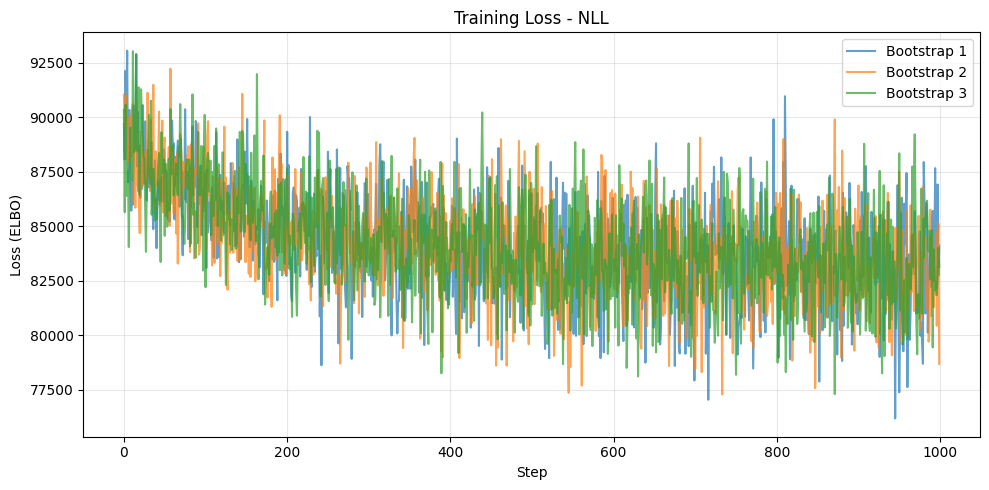


Plotting posterior distributions for NLL...


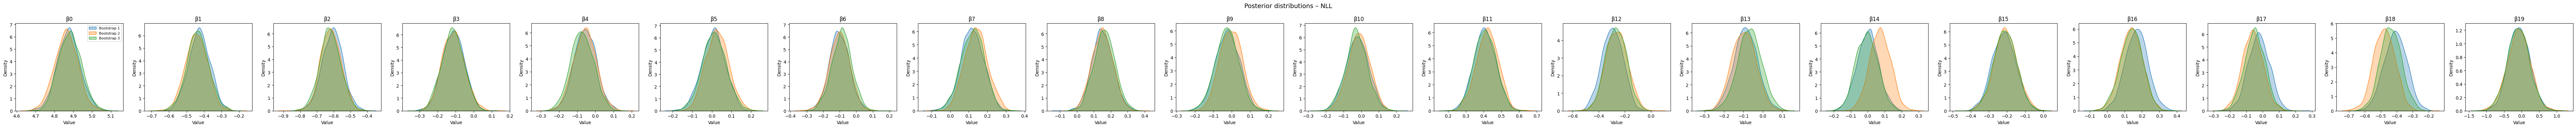


Plotting posterior α distribution for NLL...


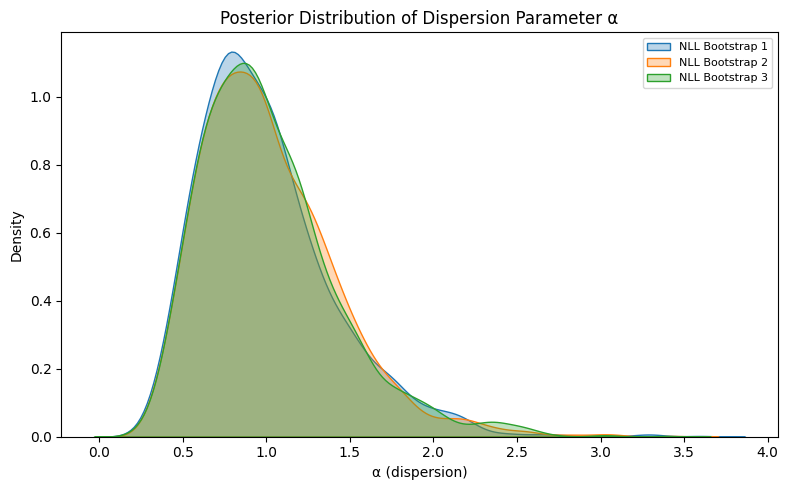


Plotting posterior predictive for NLL...

=== DEBUG posterior_predictive_nb ===
X_tensor shape: torch.Size([20, 20])
X_tensor[0, :5]: [ 1.          1.3730102  -0.361145   -0.70095795 -1.2128022 ]
betas shape: torch.Size([500, 20])
betas[0, :5]: [ 4.839503   -0.41576692 -0.53125066 -0.17713414  0.01686804]
log_mu[0, 0]: 4.397317409515381
mu[0, 0]: 81.232666015625
alpha[0, 0]: 0.5822879076004028
r[0, 0]: 1.7173634767532349
p[0, 0]: 0.9792964458465576
draws[0, :10]: [141.  70.  72. 270. 122.  51. 336.  46.  40. 178.]
draws min/max: 0.00 / 4997.00
mu_np min/max: 8.06 / 1030.20

=== DEBUG posterior_predictive_nb ===
X_tensor shape: torch.Size([20, 20])
X_tensor[0, :5]: [ 1.          1.3730102  -0.361145   -0.70095795 -1.2128022 ]
betas shape: torch.Size([500, 20])
betas[0, :5]: [ 4.7740254  -0.3843262  -0.55129945 -0.08750148 -0.08165643]
log_mu[0, 0]: 4.69691276550293
mu[0, 0]: 109.60826110839844
alpha[0, 0]: 0.9330953359603882
r[0, 0]: 1.0717018842697144
p[0, 0]: 0.9903171062469482
draws

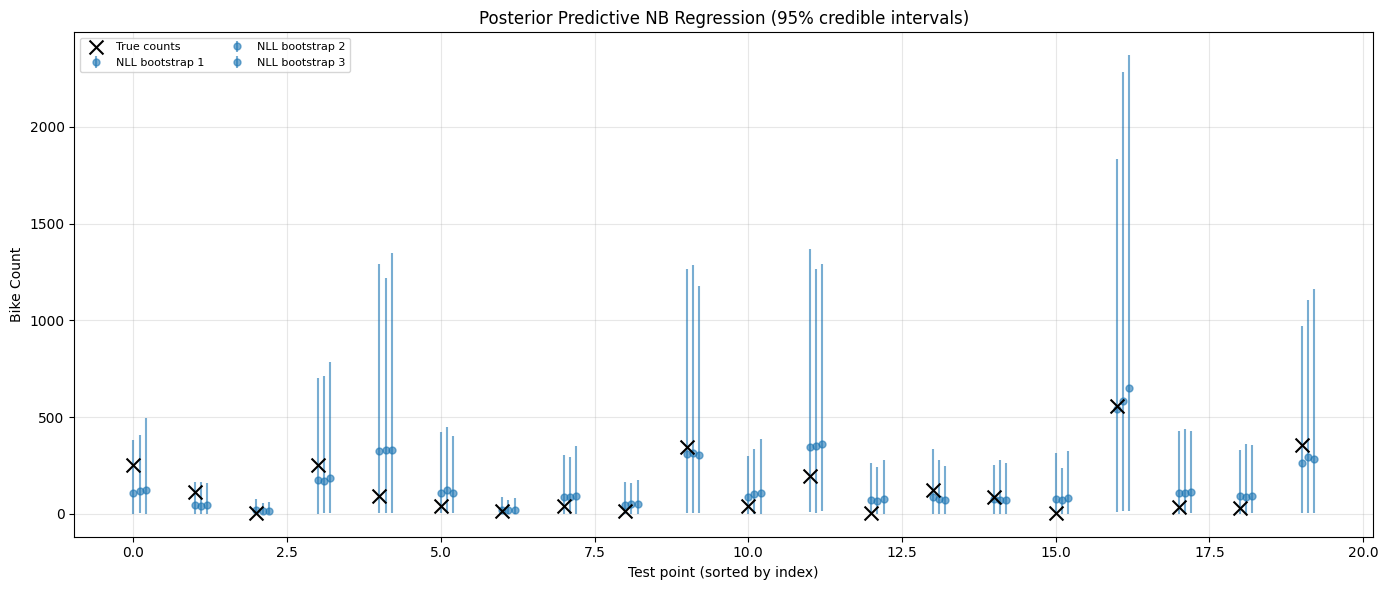


Predicted means for chosen points:
 Index  True Method  Bootstrap  Pred mean  Pred 2.5%  Pred 97.5%
    53 254.0    NLL          1 107.739998   1.000000  379.200195
    53 254.0    NLL          2 116.690002   3.000000  405.000000
    53 254.0    NLL          3 122.309998   1.000000  493.625122
   186 112.0    NLL          1  44.486000   0.000000  165.625122
   186 112.0    NLL          2  41.020000   0.000000  164.100098
   186 112.0    NLL          3  46.683998   0.000000  161.525024
   609   3.0    NLL          1  19.066000   0.000000   77.000000
   609   3.0    NLL          2  16.724001   0.000000   58.050049
   609   3.0    NLL          3  16.646000   0.000000   61.525024
   638 252.0    NLL          1 172.802002   1.475000  701.725220
   638 252.0    NLL          2 170.574005   3.000000  713.725220
   638 252.0    NLL          3 185.554001   3.000000  783.876343
   762  90.0    NLL          1 326.541992   5.000000 1289.802734
   762  90.0    NLL          2 328.067993   6.000000 1

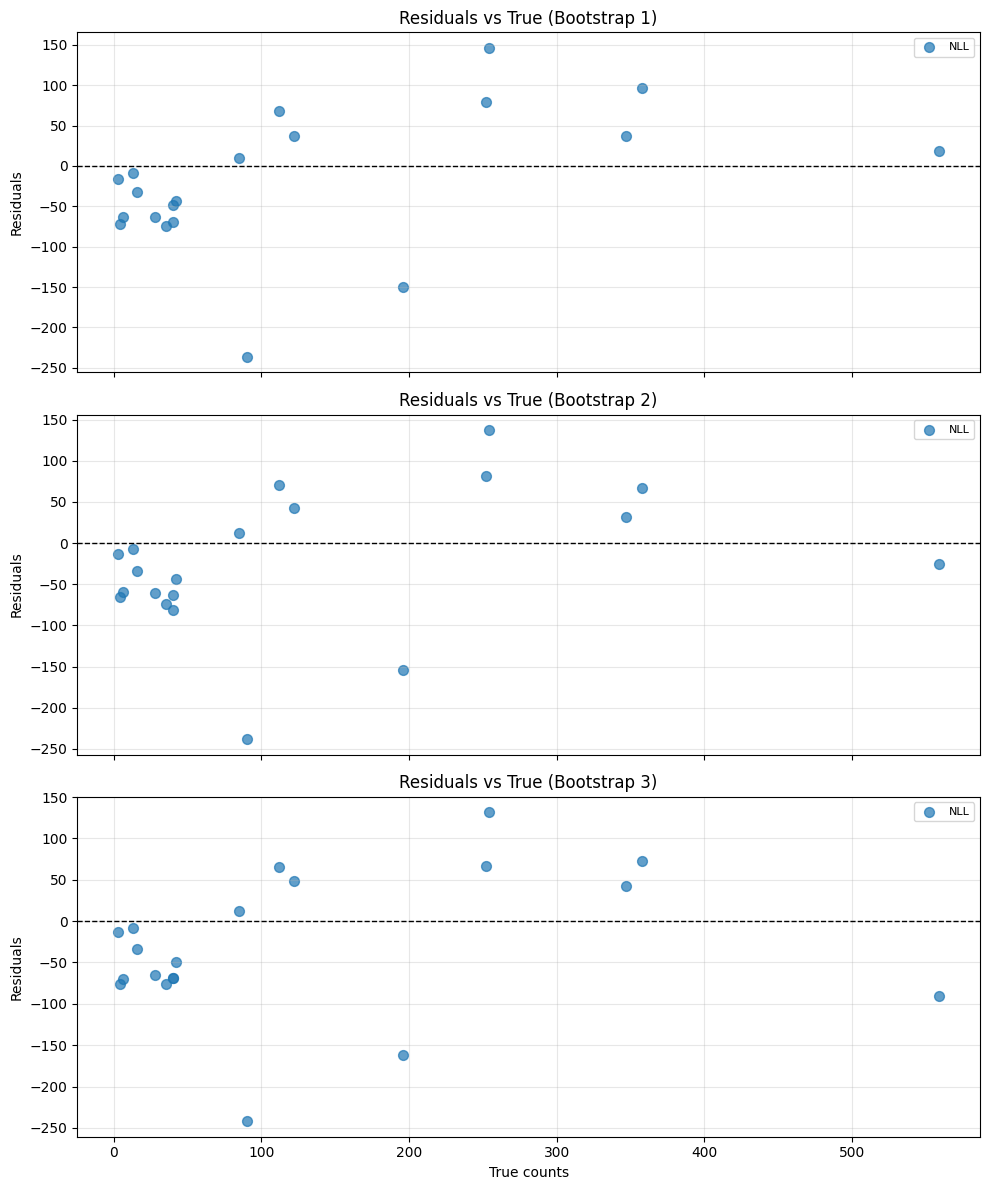


Training BETA on bootstrap 1...


/var/folders/wl/l6v7zb5d5hv77sr6wky_w9km0000gn/T/ipykernel_2323/483359622.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gammaln_r = gammaln(torch.tensor(r))
/var/folders/wl/l6v7zb5d5hv77sr6wky_w9km0000gn/T/ipykernel_2323/483359622.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  + r * (torch.log(torch.tensor(r)) - torch.log(r + mu))
/var/folders/wl/l6v7zb5d5hv77sr6wky_w9km0000gn/T/ipykernel_2323/483359622.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  + r * (torch.log(torch.tensor(r)) - torch.log(r + mu_))
/var/folders/wl

Step 100/1000, Loss: -17725.69, β₀: 5.321, α_mean: 1.110
Step 200/1000, Loss: -18686.45, β₀: 5.317, α_mean: 1.241
Step 300/1000, Loss: -19007.03, β₀: 5.290, α_mean: 1.374
Step 400/1000, Loss: -18364.18, β₀: 5.266, α_mean: 1.495
Step 500/1000, Loss: -18653.80, β₀: 5.251, α_mean: 1.583
Step 600/1000, Loss: -18292.87, β₀: 5.215, α_mean: 1.622
Step 700/1000, Loss: -18938.14, β₀: 5.188, α_mean: 1.610
Step 800/1000, Loss: -18979.67, β₀: 5.183, α_mean: 1.579
Step 900/1000, Loss: -19144.47, β₀: 5.164, α_mean: 1.566
  β₀ (intercept) = 5.1523
  α_mean = 1.5421

Training BETA on bootstrap 2...
Step 100/1000, Loss: -17751.97, β₀: 5.320, α_mean: 1.109
Step 200/1000, Loss: -18634.87, β₀: 5.319, α_mean: 1.240
Step 300/1000, Loss: -17824.90, β₀: 5.292, α_mean: 1.374
Step 400/1000, Loss: -17416.52, β₀: 5.253, α_mean: 1.497
Step 500/1000, Loss: -18769.06, β₀: 5.233, α_mean: 1.576
Step 600/1000, Loss: -18923.70, β₀: 5.202, α_mean: 1.605
Step 700/1000, Loss: -17608.52, β₀: 5.176, α_mean: 1.594
Step 800/10

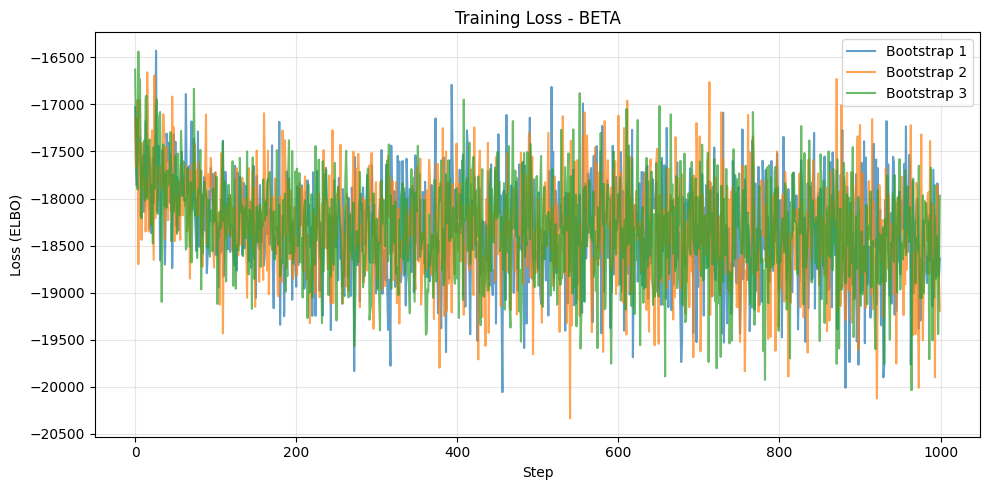


Plotting posterior distributions for BETA...


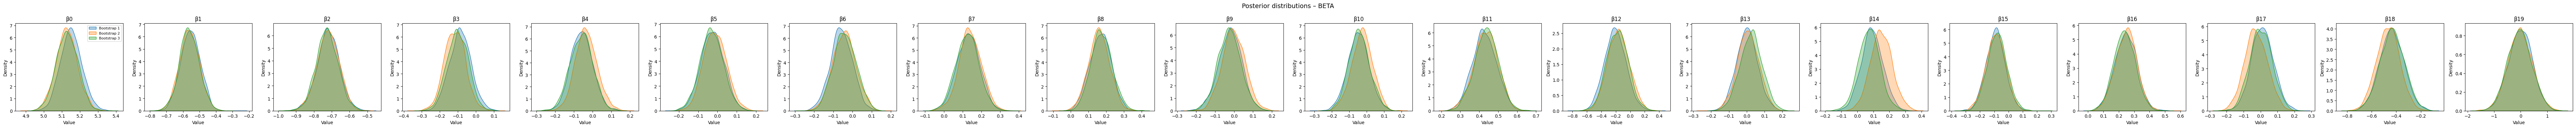


Plotting posterior α distribution for BETA...


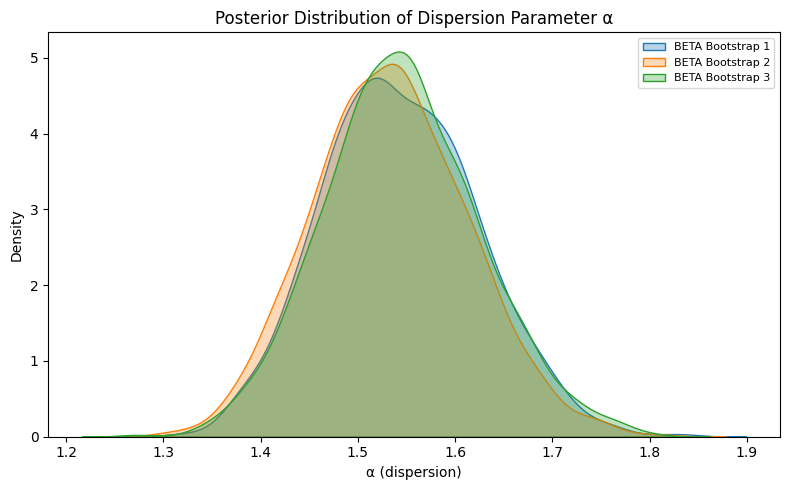


Plotting posterior predictive for BETA...

=== DEBUG posterior_predictive_nb ===
X_tensor shape: torch.Size([20, 20])
X_tensor[0, :5]: [ 1.          1.3730102  -0.361145   -0.70095795 -1.2128022 ]
betas shape: torch.Size([500, 20])
betas[0, :5]: [ 5.1186433  -0.53905445 -0.642671   -0.15004632  0.01219011]
log_mu[0, 0]: 4.8730788230896
mu[0, 0]: 130.72276306152344
alpha[0, 0]: 1.4490818977355957
r[0, 0]: 0.690092146396637
p[0, 0]: 0.9947486519813538
draws[0, :10]: [  5. 234. 111.  23.  69.   1.  53. 141. 332. 579.]
draws min/max: 0.00 / 8428.00
mu_np min/max: 8.18 / 1979.54

=== DEBUG posterior_predictive_nb ===
X_tensor shape: torch.Size([20, 20])
X_tensor[0, :5]: [ 1.          1.3730102  -0.361145   -0.70095795 -1.2128022 ]
betas shape: torch.Size([500, 20])
betas[0, :5]: [ 5.0387826  -0.5035894  -0.6558404  -0.09160106 -0.05448962]
log_mu[0, 0]: 5.135342121124268
mu[0, 0]: 169.9224395751953
alpha[0, 0]: 1.5283061265945435
r[0, 0]: 0.654319167137146
p[0, 0]: 0.9961641430854797
draws

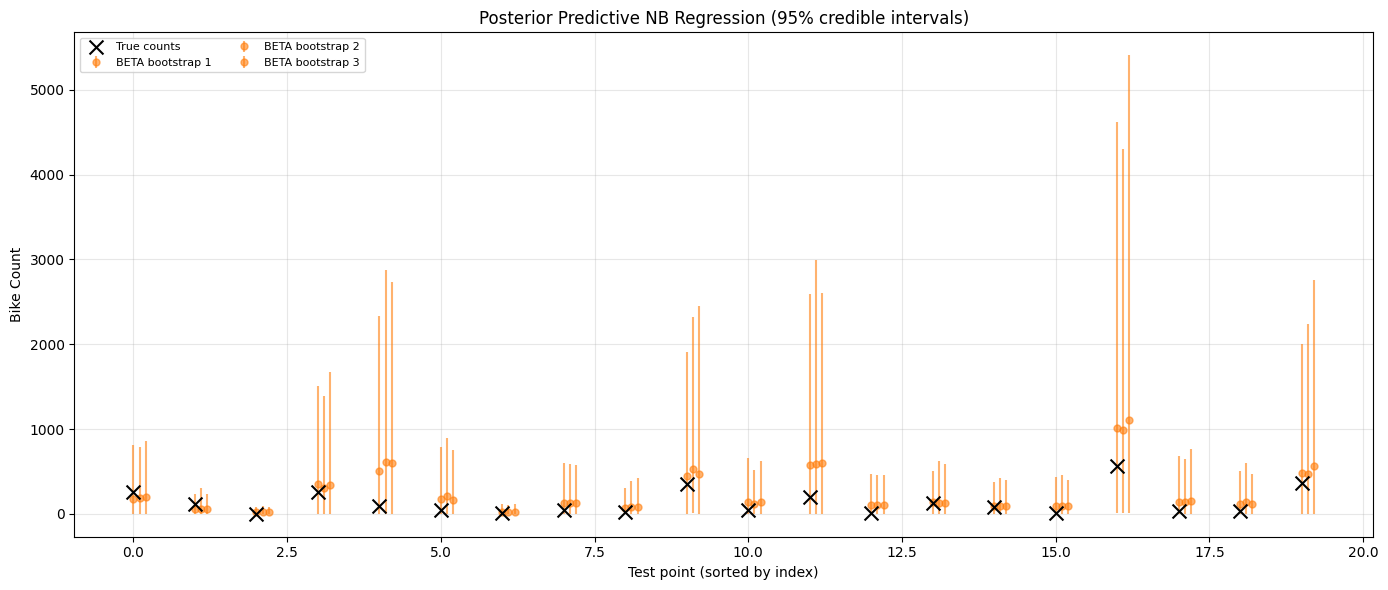


Predicted means for chosen points:
 Index  True Method  Bootstrap   Pred mean  Pred 2.5%  Pred 97.5%
    53 254.0   BETA          1  178.156006      1.000  813.451416
    53 254.0   BETA          2  181.589996      0.475  784.500488
    53 254.0   BETA          3  193.992004      0.000  856.375854
   186 112.0   BETA          1   55.203999      0.000  234.575073
   186 112.0   BETA          2   61.782001      0.000  299.575073
   186 112.0   BETA          3   56.102001      0.000  237.250244
   609   3.0   BETA          1   19.386000      0.000   84.525024
   609   3.0   BETA          2   19.062000      0.000   86.575073
   609   3.0   BETA          3   16.922001      0.000   74.575073
   638 252.0   BETA          1  347.851990      0.000 1505.850830
   638 252.0   BETA          2  300.394012      1.475 1391.500488
   638 252.0   BETA          3  338.966003      1.000 1667.650635
   762  90.0   BETA          1  509.526001      2.000 2329.250244
   762  90.0   BETA          2  614.0919

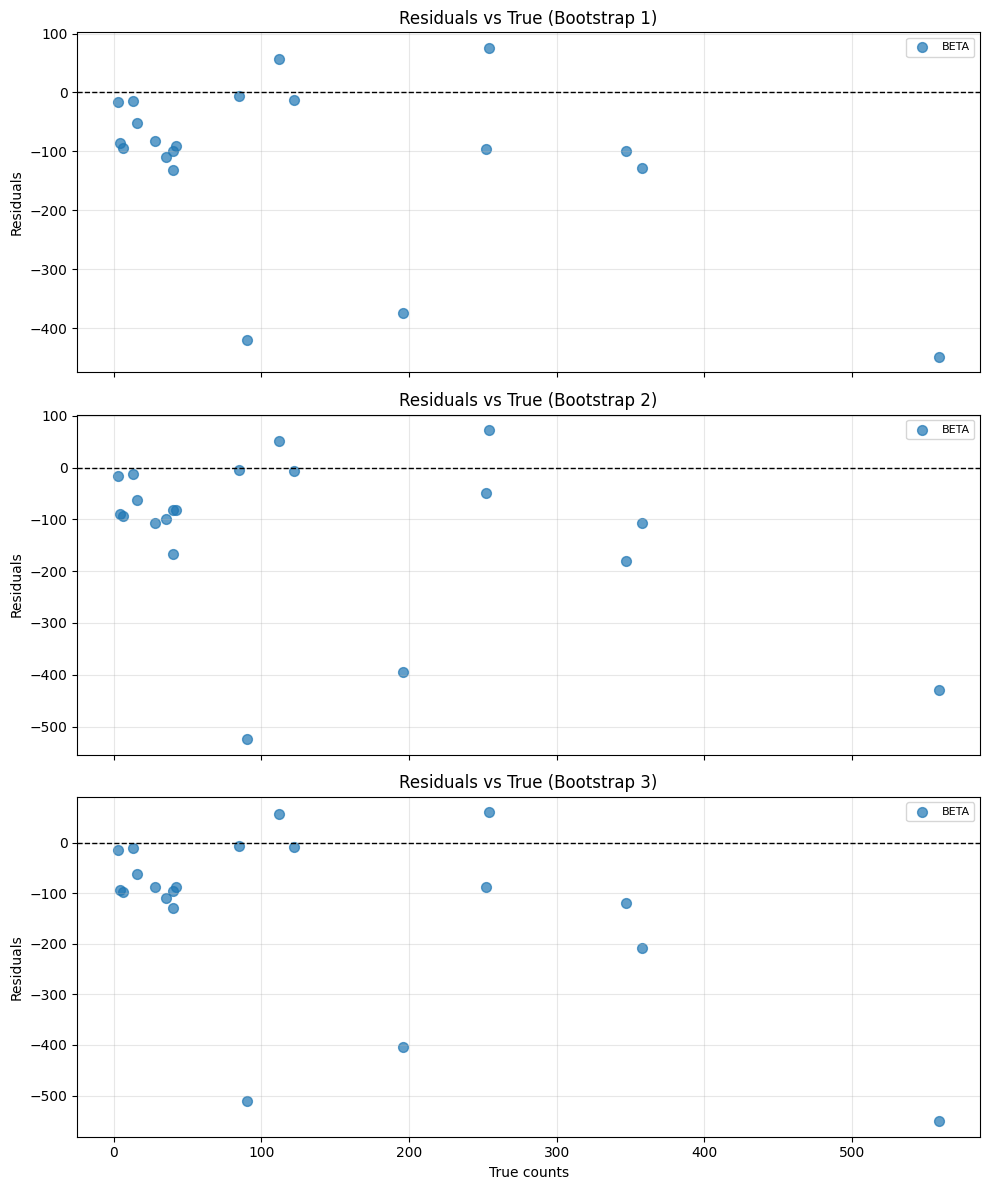


Training GAMMA on bootstrap 1...


/var/folders/wl/l6v7zb5d5hv77sr6wky_w9km0000gn/T/ipykernel_2323/483359622.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gammaln_r = gammaln(torch.tensor(r))
/var/folders/wl/l6v7zb5d5hv77sr6wky_w9km0000gn/T/ipykernel_2323/483359622.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  + r * (torch.log(torch.tensor(r)) - torch.log(r + mu))
/var/folders/wl/l6v7zb5d5hv77sr6wky_w9km0000gn/T/ipykernel_2323/483359622.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  + r * (torch.log(torch.tensor(r)) - torch.log(r + mu_))
/var/folders/wl

Step 100/1000, Loss: 278520.47, β₀: 5.330, α_mean: 1.111
Step 200/1000, Loss: 273727.34, β₀: 5.353, α_mean: 1.248
Step 300/1000, Loss: 270482.28, β₀: 5.336, α_mean: 1.394
Step 400/1000, Loss: 279174.69, β₀: 5.322, α_mean: 1.551
Step 500/1000, Loss: 273015.56, β₀: 5.293, α_mean: 1.722
Step 600/1000, Loss: 283844.28, β₀: 5.278, α_mean: 1.904
Step 700/1000, Loss: 280489.75, β₀: 5.264, α_mean: 2.101
Step 800/1000, Loss: 272863.00, β₀: 5.247, α_mean: 2.311
Step 900/1000, Loss: 283179.00, β₀: 5.235, α_mean: 2.528
  β₀ (intercept) = 5.2267
  α_mean = 2.7478

Training GAMMA on bootstrap 2...
Step 100/1000, Loss: 273728.47, β₀: 5.327, α_mean: 1.114
Step 200/1000, Loss: 271024.06, β₀: 5.351, α_mean: 1.250
Step 300/1000, Loss: 277591.62, β₀: 5.338, α_mean: 1.396
Step 400/1000, Loss: 281692.75, β₀: 5.310, α_mean: 1.553
Step 500/1000, Loss: 276540.78, β₀: 5.296, α_mean: 1.721
Step 600/1000, Loss: 276287.44, β₀: 5.266, α_mean: 1.904
Step 700/1000, Loss: 277686.88, β₀: 5.250, α_mean: 2.101
Step 800/1

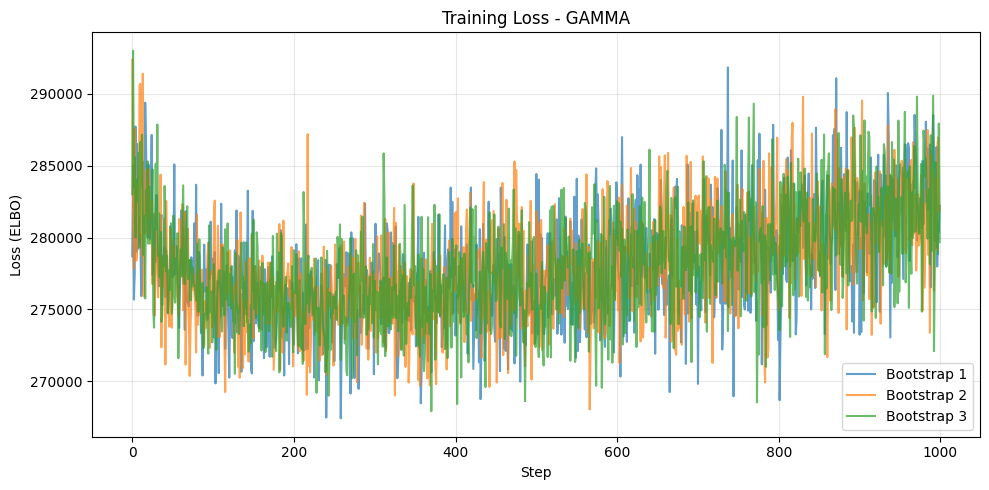


Plotting posterior distributions for GAMMA...


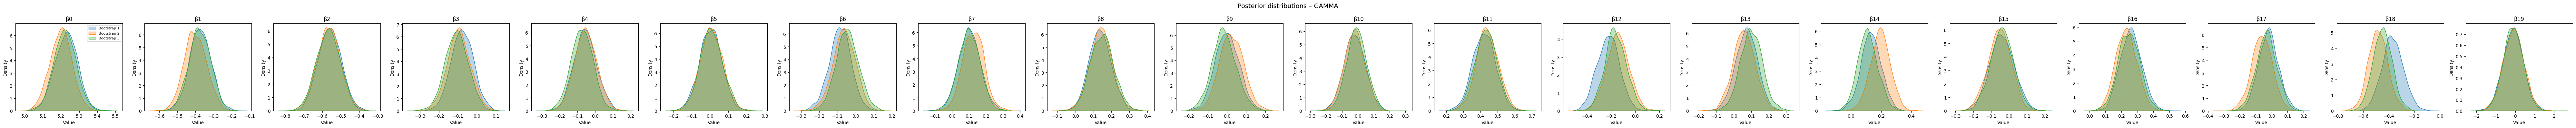


Plotting posterior α distribution for GAMMA...


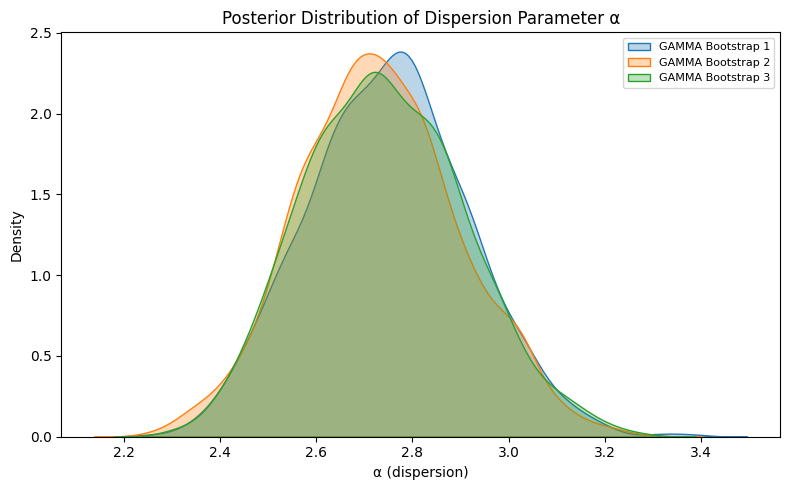


Plotting posterior predictive for GAMMA...

=== DEBUG posterior_predictive_nb ===
X_tensor shape: torch.Size([20, 20])
X_tensor[0, :5]: [ 1.          1.3730102  -0.361145   -0.70095795 -1.2128022 ]
betas shape: torch.Size([500, 20])
betas[0, :5]: [ 5.191866   -0.35908568 -0.4828899  -0.14298628  0.0188334 ]
log_mu[0, 0]: 5.089416980743408
mu[0, 0]: 162.2952117919922
alpha[0, 0]: 2.5532679557800293
r[0, 0]: 0.39165493845939636
p[0, 0]: 0.9975926280021667
draws[0, :10]: [  0. 214. 139.   6.  39.   0.  39. 164. 263. 986.]
draws min/max: 0.00 / 11423.00
mu_np min/max: 16.35 / 1580.51

=== DEBUG posterior_predictive_nb ===
X_tensor shape: torch.Size([20, 20])
X_tensor[0, :5]: [ 1.          1.3730102  -0.361145   -0.70095795 -1.2128022 ]
betas shape: torch.Size([500, 20])
betas[0, :5]: [ 5.107677   -0.33839792 -0.50063765 -0.06933924 -0.07408328]
log_mu[0, 0]: 5.390571594238281
mu[0, 0]: 219.32872009277344
alpha[0, 0]: 2.7226219177246094
r[0, 0]: 0.36729300022125244
p[0, 0]: 0.9983281493186

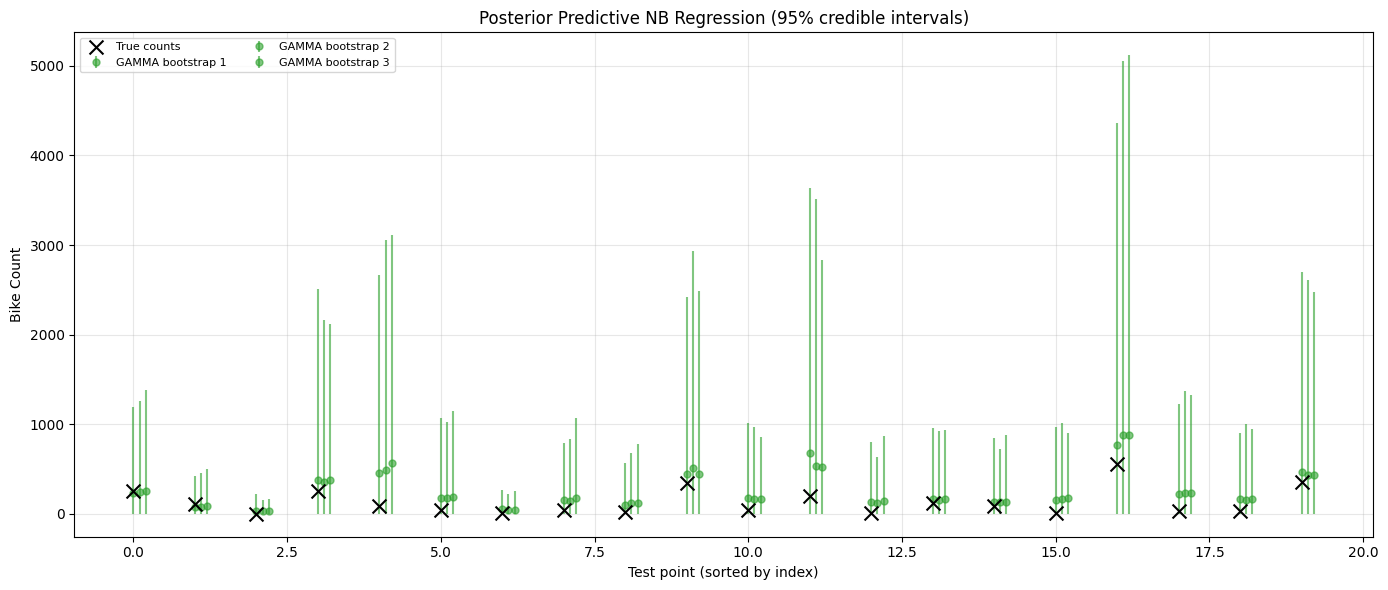


Predicted means for chosen points:
 Index  True Method  Bootstrap  Pred mean  Pred 2.5%  Pred 97.5%
    53 254.0  GAMMA          1 228.322006        0.0 1192.726196
    53 254.0  GAMMA          2 248.378006        0.0 1261.028442
    53 254.0  GAMMA          3 259.566010        0.0 1382.000000
   186 112.0  GAMMA          1  73.580002        0.0  424.300293
   186 112.0  GAMMA          2  79.690002        0.0  456.500488
   186 112.0  GAMMA          3  85.694000        0.0  496.325806
   609   3.0  GAMMA          1  36.764000        0.0  221.675171
   609   3.0  GAMMA          2  28.406000        0.0  152.675171
   609   3.0  GAMMA          3  29.906000        0.0  168.550537
   638 252.0  GAMMA          1 381.123993        0.0 2508.879395
   638 252.0  GAMMA          2 350.497986        0.0 2158.578125
   638 252.0  GAMMA          3 380.096008        0.0 2119.301270
   762  90.0  GAMMA          1 455.910004        0.0 2661.725098
   762  90.0  GAMMA          2 488.131989        0.0 3

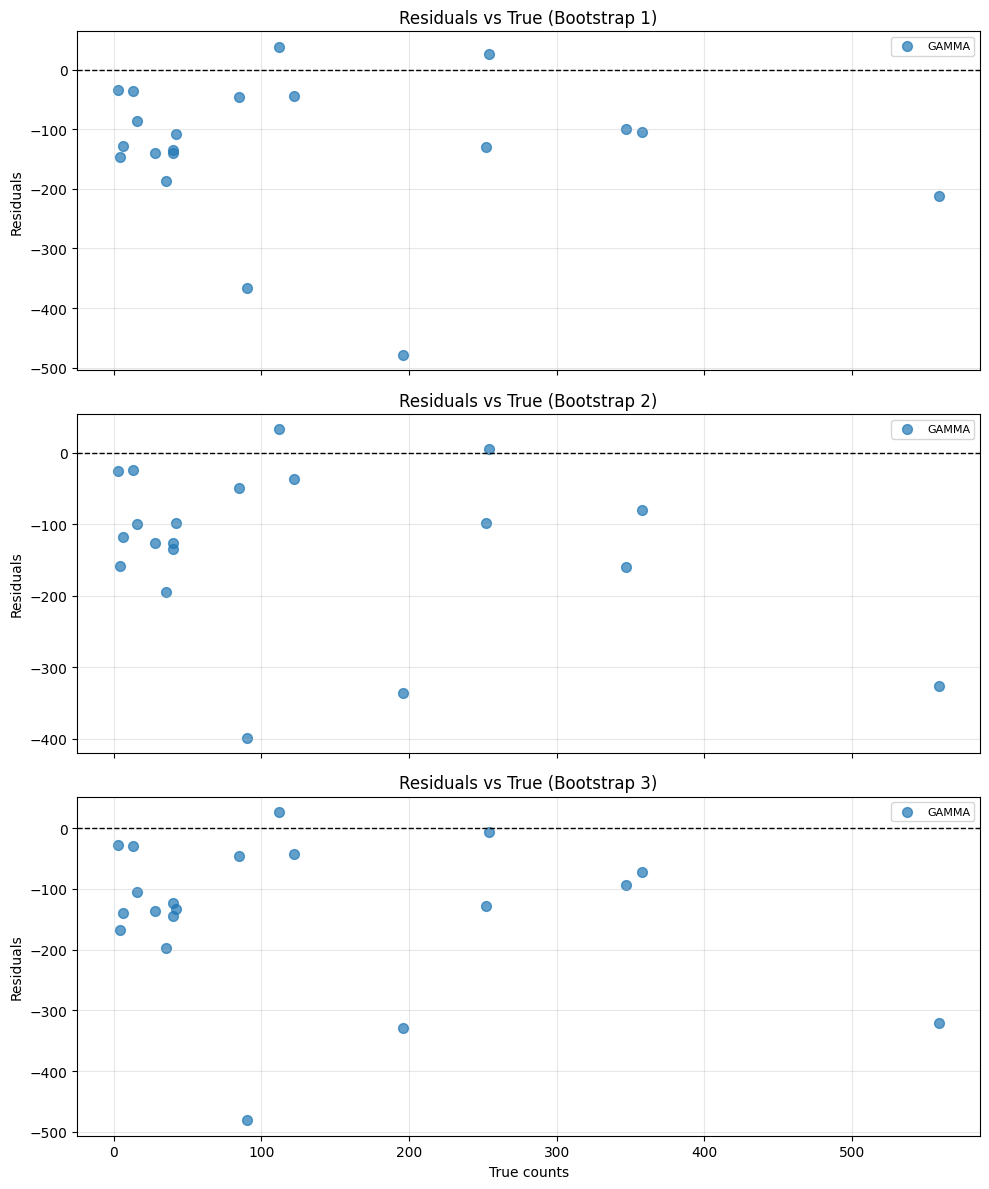

In [671]:
import matplotlib.pyplot as plt

BATCH_SIZE = 64
MC_SAMPLES = 100
STEPS      = 1000
LR         = 1e-3
SEED       = 123

methods = [
    ("nll",   {}),                    
    ("beta",  {"beta_div": 1.2}),    
    ("gamma", {"gamma_param": 0.9}),  
]

feature_names = ["Intercept"] + df.drop(
    columns=['instant', 'dteday', 'cnt', 'casual', 'registered']
).columns.tolist()

trained_results = {}

for method, params in methods:
    q_list = []
    loss_histories = []
    
    for j, (X_bs, y_bs) in enumerate(bootstraps, 1):
        print(f"\nTraining {method.upper()} on bootstrap {j}...")
        
        if method == "nll":
            qj, loss_hist = train_nb_gvi(
                X_bs, y_bs,
                loss_type="nll",
                steps=STEPS, lr=LR,
                batch_size=BATCH_SIZE, mc_samples=MC_SAMPLES,
                prior_mean_beta=prior_mean_beta,
                prior_cov_inv=prior_cov_inv,
                logdet_prior_cov=logdet_prior_cov,
                lambda_alpha=prior_lambda_alpha,
                device="cpu"
            )
        elif method == "beta":
            qj, loss_hist = train_nb_gvi(
                X_bs, y_bs,
                loss_type="beta",
                beta_div=params["beta_div"],
                steps=STEPS, lr=LR,
                batch_size=BATCH_SIZE, mc_samples=MC_SAMPLES,
                prior_mean_beta=prior_mean_beta,
                prior_cov_inv=prior_cov_inv,
                logdet_prior_cov=logdet_prior_cov,
                lambda_alpha=prior_lambda_alpha,
                device="cpu"
            )
        elif method == "gamma":
            qj, loss_hist = train_nb_gvi(
                X_bs, y_bs,
                loss_type="gamma",
                gamma_div=params["gamma_param"],
                steps=STEPS, lr=LR,
                batch_size=BATCH_SIZE, mc_samples=MC_SAMPLES,
                prior_mean_beta=prior_mean_beta,
                prior_cov_inv=prior_cov_inv,
                logdet_prior_cov=logdet_prior_cov,
                lambda_alpha=prior_lambda_alpha,
                device="cpu"
            )
        else:
            raise RuntimeError("Unknown method")
        
        q_list.append(qj)
        loss_histories.append(loss_hist)
        with torch.no_grad():
            beta_mean = qj.m_beta.cpu().numpy()
            alpha_mean = torch.exp(qj.m_alpha + 0.5 * torch.exp(2 * qj.log_s_alpha)).item()
            print(f"  β₀ (intercept) = {beta_mean[0]:.4f}")
            print(f"  α_mean = {alpha_mean:.4f}")
    
    trained_results[method] = q_list

    print(f"\nPlotting posterior distributions for {method.upper()}...")
    plot_posteriors_all_betas_nb(
        {method: q_list},
        num_samples=2000,
        feature_names=feature_names
    )

    print(f"\nPlotting posterior α distribution for {method.upper()}...")
    plot_posterior_alpha_nb(
        {method: q_list},
        num_samples=2000
    )

    print(f"\nPlotting posterior predictive for {method.upper()}...")
    df_preds = plot_posterior_predictive_points_nb(
        {method: q_list},
        X_test_np, y_test_np,
        num_points=20, num_samples=500,
        seed=SEED,
        fixed_ylim=None,
        show_residuals=True
    )





In [672]:
import numpy as np
import pandas as pd

def compute_crps(y_true, y_samples):
    """
    Compute CRPS (Continuous Ranked Probability Score) for each prediction.
    
    CRPS measures the difference between the predicted cumulative distribution
    and the empirical distribution of the observation.
    
    Lower is better (0 = perfect prediction).
    
    Args:
        y_true: (N,) array of true values
        y_samples: (N, S) array of posterior predictive samples
    
    Returns:
        crps: (N,) array of CRPS values
    """
    N, S = y_samples.shape
    crps = np.zeros(N)
    
    for i in range(N):
        # Sort samples for this observation
        samples_sorted = np.sort(y_samples[i, :])
        
        # Empirical CDF of samples
        # CRPS = E[|Y - y_true|] - 0.5 * E[|Y - Y'|]
        # where Y, Y' are independent draws from the predictive distribution
        
        # Term 1: Average absolute difference from true value
        term1 = np.mean(np.abs(samples_sorted - y_true[i]))
        
        # Term 2: Average absolute difference between all sample pairs
        # This can be computed efficiently
        term2 = 0.0
        for j in range(S):
            for k in range(S):
                term2 += np.abs(samples_sorted[j] - samples_sorted[k])
        term2 = term2 / (2 * S * S)
        
        crps[i] = term1 - term2
    
    return crps


def evaluate_predictions_nb(results, X_test, y_test, num_samples=500):
    """
    Evaluate predictive performance: MAE, RMSE, CRPS, coverage, interval width.
    
    Args:
        results: dict of {method_name: [q1, q2, q3, ...]}
        X_test: test features (N, D)
        y_test: true test counts (N,)
        num_samples: number of posterior predictive samples
    
    Returns:
        DataFrame with metrics for each method and bootstrap
    """
    metrics = []
    
    for method, q_list in results.items():
        for b, q in enumerate(q_list, 1):
            
            # Generate predictions
            mu_samples, alpha_samples, y_samples = posterior_predictive_nb(
                q, X_test, num_samples=num_samples
            )
            
            # Compute summary statistics
            pred_mean = y_samples.mean(axis=1)
            lower = np.percentile(y_samples, 2.5, axis=1)
            upper = np.percentile(y_samples, 97.5, axis=1)
            
            # Compute CRPS
            crps_values = compute_crps(y_test, y_samples)
            mean_crps = np.mean(crps_values)
            
            # Compute metrics
            mae = np.mean(np.abs(y_test - pred_mean))
            rmse = np.sqrt(np.mean((y_test - pred_mean) ** 2))
            coverage = np.mean((y_test >= lower) & (y_test <= upper))
            avg_width = np.mean(upper - lower)
            
            metrics.append({
                "Method": method.upper(),
                "Bootstrap": b,
                "MAE": mae,
                "RMSE": rmse,
                "CRPS": mean_crps,
                "Coverage (95%)": coverage,
                "Avg Interval Width": avg_width
            })
    
    df_metrics = pd.DataFrame(metrics)
    print("\nPredictive Performance Metrics:")
    print(df_metrics.to_string(index=False))
    
    return df_metrics


In [673]:
# Evaluate all your trained models
df_metrics = evaluate_predictions_nb(
    trained_results,  # {"nll": [q1, q2, q3], "beta": [q1, q2, q3]}
    X_test_np,
    y_test_np,
    num_samples=500
)

# Check average coverage across bootstraps
print("\n" + "="*60)
print("Average metrics by method:")
print(df_metrics.groupby("Method")[["MAE", "RMSE", "CRPS", "Coverage (95%)", "Avg Interval Width"]].mean())



=== DEBUG posterior_predictive_nb ===
X_tensor shape: torch.Size([3476, 20])
X_tensor[0, :5]: [ 1.         1.0068225  1.0043185 -1.2198375 -0.6963595]
betas shape: torch.Size([500, 20])
betas[0, :5]: [ 4.9196496  -0.35983628 -0.6611929  -0.11848149  0.01652577]
log_mu[0, 0]: 4.086029529571533
mu[0, 0]: 59.50316619873047
alpha[0, 0]: 0.8777916431427002
r[0, 0]: 1.139222502708435
p[0, 0]: 0.9812141060829163
draws[0, :10]: [ 57.  26.  10. 182.  36.  82.  36.  41.  41.   7.]
draws min/max: 0.00 / 17195.00
mu_np min/max: 5.40 / 2880.27

=== DEBUG posterior_predictive_nb ===
X_tensor shape: torch.Size([3476, 20])
X_tensor[0, :5]: [ 1.         1.0068225  1.0043185 -1.2198375 -0.6963595]
betas shape: torch.Size([500, 20])
betas[0, :5]: [ 4.850122   -0.49548662 -0.5456604  -0.15256178 -0.10151671]
log_mu[0, 0]: 3.9309308528900146
mu[0, 0]: 50.95438766479492
alpha[0, 0]: 0.9100182056427002
r[0, 0]: 1.098879098892212
p[0, 0]: 0.9788892865180969
draws[0, :10]: [ 46.  55.  17. 162.  23.  11.   5. 

In [ ]:
y_mean = np.mean(y_train)
baseline_crps = np.mean(np.abs(y_test - y_mean))
print("Baseline CRPS:", baseline_crps)


Baseline CRPS: 140.25331505307983


In [664]:
import torch
from torch.special import gammaln
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# Divergence functions (with proper tensor handling)
# ============================================================================


# ============================================================================
# Test function
# ============================================================================

def test_divergence_convergence():
    """Test that divergences converge to NLL"""
    
    print("="*80)
    print("TESTING DIVERGENCE CONVERGENCE TO NLL")
    print("="*80)
    
    # ---- Create synthetic data ----
    torch.manual_seed(42)
    n_samples = 100
    n_features = 5
    
    X = torch.randn(n_samples, n_features)
    beta_true = torch.randn(n_features)
    alpha_true = 0.5
    
    # Generate NB samples using Gamma-Poisson mixture
    mu_true = torch.exp(X @ beta_true)
    r_true = 1.0 / alpha_true
    
    # Create distributions
    concentration = torch.full((n_samples,), r_true)
    rate = r_true / mu_true
    gamma_dist = torch.distributions.Gamma(concentration, rate)
    lambda_samples = gamma_dist.sample()
    
    poisson_dist = torch.distributions.Poisson(lambda_samples)
    y = poisson_dist.sample()
    
    print(f"\nGenerated data:")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
    print(f"  y range: [{y.min():.1f}, {y.max():.1f}]")
    print(f"  y mean: {y.mean():.2f}")
    
    # ---- Compute reference NLL ----
    nll_ref = nll_loss_nb(X, y, beta_true, alpha_true)
    print(f"\nReference NLL: {nll_ref.item():.6f}")
    
    # ============================================================================
    # Test 1: β-divergence as β → 1⁺
    # ============================================================================
    print("\n" + "-"*80)
    print("TEST 1: β-divergence convergence (β → 1⁺)")
    print("-"*80)
    
    beta_values = [2.0, 1.5, 1.2, 1.1, 1.05, 1.01, 1.001, 1.0001]
    beta_losses = []
    
    print(f"{'β':>10s} {'β-div Loss':>15s} {'NLL':>15s} {'|Difference|':>15s} {'Rel. Error':>15s}")
    print("-"*80)
    
    for beta_val in beta_values:
        loss_beta = beta_loss_nb(X, y, beta_true, alpha_true, beta_val, trunc=200)
        diff = abs(loss_beta.item() - nll_ref.item())
        rel_error = diff / abs(nll_ref.item())
        
        beta_losses.append(loss_beta.item())
        
        print(f"{beta_val:10.4f} {loss_beta.item():15.6f} {nll_ref.item():15.6f} "
              f"{diff:15.6e} {rel_error:15.6e}")
    
    # Check convergence
    final_error_beta = abs(beta_losses[-1] - nll_ref.item()) / abs(nll_ref.item())
    if final_error_beta < 1e-3:
        print(f"\n✅ PASS: β-divergence converges to NLL (rel. error = {final_error_beta:.2e})")
    else:
        print(f"\n❌ FAIL: β-divergence does not converge (rel. error = {final_error_beta:.2e})")
    
    # ============================================================================
    # Test 2: γ-divergence as γ → 1⁻
    # ============================================================================
    print("\n" + "-"*80)
    print("TEST 2: γ-divergence convergence (γ → 1⁻)")
    print("-"*80)
    
    gamma_values = [0.0, 0.5, 0.8, 0.9, 0.95, 0.99, 0.999, 0.9999]
    gamma_losses = []
    
    print(f"{'γ':>10s} {'γ-div Loss':>15s} {'NLL':>15s} {'|Difference|':>15s} {'Rel. Error':>15s}")
    print("-"*80)
    
    for gamma_val in gamma_values:
        loss_gamma = gamma_loss_nb(X, y, beta_true, alpha_true, gamma_val, trunc=200)
        diff = abs(loss_gamma.item() - nll_ref.item())
        rel_error = diff / abs(nll_ref.item())
        
        gamma_losses.append(loss_gamma.item())
        
        print(f"{gamma_val:10.4f} {loss_gamma.item():15.6f} {nll_ref.item():15.6f} "
              f"{diff:15.6e} {rel_error:15.6e}")
    
    # Check convergence
    final_error_gamma = abs(gamma_losses[-1] - nll_ref.item()) / abs(nll_ref.item())
    if final_error_gamma < 1e-3:
        print(f"\n✅ PASS: γ-divergence converges to NLL (rel. error = {final_error_gamma:.2e})")
    else:
        print(f"\n❌ FAIL: γ-divergence does not converge (rel. error = {final_error_gamma:.2e})")
    
    # ============================================================================
    # Visualization
    # ============================================================================
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: β-divergence
    ax1.plot(beta_values, beta_losses, 'o-', label='β-divergence', linewidth=2, markersize=8)
    ax1.axhline(nll_ref.item(), color='red', linestyle='--', label='NLL', linewidth=2)
    ax1.set_xlabel('β', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('β-divergence → NLL as β → 1⁺', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0.9, 2.1])
    
    # Plot 2: γ-divergence
    ax2.plot(gamma_values, gamma_losses, 's-', label='γ-divergence', 
             linewidth=2, markersize=8, color='green')
    ax2.axhline(nll_ref.item(), color='red', linestyle='--', label='NLL', linewidth=2)
    ax2.set_xlabel('γ', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('γ-divergence → NLL as γ → 1⁻', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([-0.1, 1.1])
    
    plt.tight_layout()
    plt.savefig('divergence_convergence.png', dpi=150, bbox_inches='tight')
    print("\n📊 Plot saved to 'divergence_convergence.png'")
    plt.show()
    
    # ============================================================================
    # Summary
    # ============================================================================
    print("\n" + "="*80)
    print("SUMMARY")
    print("="*80)
    
    beta_converged = final_error_beta < 1e-3
    gamma_converged = final_error_gamma < 1e-3
    
    print(f"β-divergence convergence:  {'✅ PASS' if beta_converged else '❌ FAIL'}")
    print(f"γ-divergence convergence:  {'✅ PASS' if gamma_converged else '❌ FAIL'}")
    
    if beta_converged and gamma_converged:
        print("\n🎉 All tests passed! Divergences correctly converge to NLL.")
    else:
        print("\n⚠️  Some tests failed. Check implementation.")
    
    return {
        'nll_ref': nll_ref.item(),
        'beta_values': beta_values,
        'beta_losses': beta_losses,
        'gamma_values': gamma_values,
        'gamma_losses': gamma_losses,
        'beta_converged': beta_converged,
        'gamma_converged': gamma_converged,
    }


# ============================================================================
# Run test
# ============================================================================

if __name__ == "__main__":
    results = test_divergence_convergence()

TESTING DIVERGENCE CONVERGENCE TO NLL

Generated data:
  X shape: torch.Size([100, 5])
  y shape: torch.Size([100])
  y range: [0.0, 131.0]
  y mean: 4.65

Reference NLL: 167.076294

--------------------------------------------------------------------------------
TEST 1: β-divergence convergence (β → 1⁺)
--------------------------------------------------------------------------------
         β      β-div Loss             NLL    |Difference|      Rel. Error
--------------------------------------------------------------------------------
    2.0000      -17.737484      167.076294    1.848138e+02    1.106164e+00
    1.5000      -69.993942      167.076294    2.370702e+02    1.418934e+00
    1.2000     -308.748383      167.076294    4.758247e+02    2.847948e+00
    1.1000     -776.140991      167.076294    9.432173e+02    5.645429e+00
    1.0500    -1756.134155      167.076294    1.923210e+03    1.151097e+01
    1.0100    -9737.880859      167.076294    9.904957e+03    5.928404e+01
    1.0

ZeroDivisionError: float division by zero